# 03 - Hierarchical Player Tracking
## RF-DETR + Kalman + Re-ID + Selective SAM2

### Objective

Develop an efficient multi-object tracking pipeline for basketball players
that separates high-frequency tracking from high-precision anomaly resolution.

The system follows a hierarchical strategy:

1. **RF-DETR** detects players in each frame.
2. **Kalman filtering + geometric association** handle normal tracking.
3. **Re-Identification** is activated only when geometric association becomes uncertain.
4. **SAM2** is activated only for ambiguous collisions or partial occlusions.
5. SAM2 is used as a **stateless local segmentation module**, not as a continuous video tracker.

Pipeline:

Video
→ RF-DETR detections
→ Kalman prediction
→ geometric association
→ Re-ID if ambiguous
→ SAM2 only if ambiguity remains
→ stable player track IDs

### Main goals

- Reduce ID switches.
- Reduce track fragmentation.
- Avoid unnecessary Re-ID inference.
- Avoid continuous SAM2 video memory.
- Measure both tracking accuracy and computational cost.

In [1]:
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm

from rfdetr import RFDETRNano


print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("OpenCV:", cv2.__version__)

print()
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Python: /Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/bin/python
NumPy: 2.3.5
Torch: 2.14.0
OpenCV: 5.0.0

CUDA available: False
MPS available: True


In [2]:
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Selected device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Selected device: mps


In [3]:
DRIVE_ROOT = Path(
    "/Users/marcodalbis/Library/CloudStorage/"
    "GoogleDrive-marco.dalbis@gmail.com/"
    "Il mio Drive/"
    "basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

FRAMES_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "img1"
)

GT_PATH = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "gt"
    / "gt.txt"
)

CHECKPOINT_PATH = (
    DRIVE_ROOT
    / "checkpoints"
    / "rfdetr_nano_10epochs"
    / "checkpoint_best_total.pth"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "hierarchical_tracking"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("DRIVE_ROOT:", DRIVE_ROOT)
print("Frames:", FRAMES_DIR)
print("Ground truth:", GT_PATH)
print("Checkpoint:", CHECKPOINT_PATH)
print("Output:", OUTPUT_DIR)

DRIVE_ROOT: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis
Frames: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001/img1
Ground truth: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001/gt/gt.txt
Checkpoint: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/checkpoints/rfdetr_nano_10epochs/checkpoint_best_total.pth
Output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking


In [4]:
assert DRIVE_ROOT.exists(), f"Missing DRIVE_ROOT: {DRIVE_ROOT}"
assert FRAMES_DIR.exists(), f"Missing frames directory: {FRAMES_DIR}"
assert GT_PATH.exists(), f"Missing ground truth: {GT_PATH}"
assert CHECKPOINT_PATH.exists(), f"Missing RF-DETR checkpoint: {CHECKPOINT_PATH}"

print("All required paths are valid.")

All required paths are valid.


In [5]:
NUM_FRAMES = 1162

DETECTION_THRESHOLD = 0.30

PLAYER_CLASS_ID = 0

print("Sequence:", SEQUENCE_NAME)
print("Frames:", NUM_FRAMES)
print("Detection threshold:", DETECTION_THRESHOLD)

Sequence: v_00HRwkvvjtQ_c001
Frames: 1162
Detection threshold: 0.3


In [6]:
frame_paths = [
    FRAMES_DIR / f"{frame_number:06d}.jpg"
    for frame_number in range(1, NUM_FRAMES + 1)
]

missing_frames = [
    path
    for path in frame_paths
    if not path.exists()
]

print("Frames expected:", len(frame_paths))
print("Missing frames:", len(missing_frames))

if missing_frames:
    print("First missing frames:")
    print(missing_frames[:10])

assert len(missing_frames) == 0

Frames expected: 1162
Missing frames: 0


Frame: 100
Shape: (720, 1280, 3)


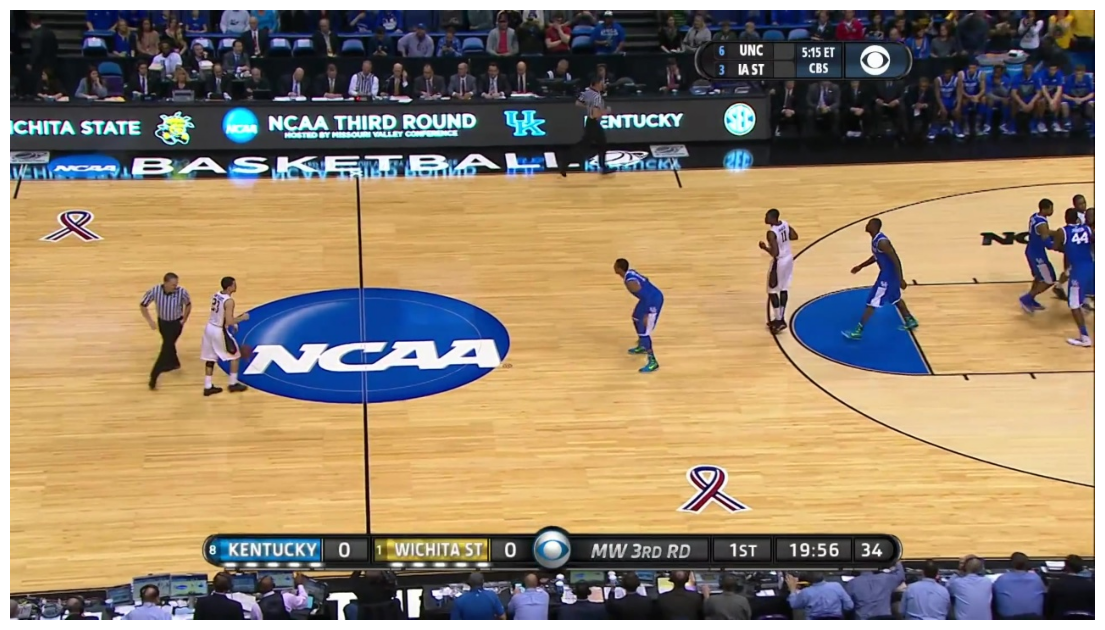

In [7]:
SAMPLE_FRAME_NUMBER = 100

sample_frame_path = frame_paths[
    SAMPLE_FRAME_NUMBER - 1
]

sample_frame = cv2.imread(
    str(sample_frame_path)
)

assert sample_frame is not None

sample_rgb = cv2.cvtColor(
    sample_frame,
    cv2.COLOR_BGR2RGB
)

print("Frame:", SAMPLE_FRAME_NUMBER)
print("Shape:", sample_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(sample_rgb)
plt.axis("off")
plt.show()

In [8]:
PLAYER_DETECTION_MODEL = RFDETRNano(
    pretrain_weights=str(CHECKPOINT_PATH)
)

print("RF-DETR loaded.")

[2026-10-08 18:00:10] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-08 18:00:10] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-08 18:00:43] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


RF-DETR loaded.


In [9]:
test_frame = cv2.imread(
    str(frame_paths[SAMPLE_FRAME_NUMBER - 1])
)

test_frame_rgb = cv2.cvtColor(
    test_frame,
    cv2.COLOR_BGR2RGB
)

start_time = time.perf_counter()

result = PLAYER_DETECTION_MODEL.predict(
    test_frame_rgb,
    threshold=DETECTION_THRESHOLD
)

elapsed = time.perf_counter() - start_time

print("Inference completed.")
print(f"Elapsed time: {elapsed:.4f} s")
print("Raw result type:", type(result))

[2026-10-08 18:00:43] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Inference completed.
Elapsed time: 0.8632 s
Raw result type: <class 'supervision.detection.core.Detections'>


In [10]:
print(result)

Detections(xyxy=array([[ 982.7642 ,  242.7071 , 1073.9391 ,  391.00772],
       [ 711.08496,  291.93082,  772.9403 ,  429.3557 ],
       [1145.945  ,  221.41728, 1246.9462 ,  359.02756],
       [ 225.37137,  313.28668,  282.2565 ,  456.65463],
       [ 883.3713 ,  233.00153,  930.4125 ,  393.3072 ],
       [1232.2896 ,  218.3671 , 1279.708  ,  397.87967],
       [ 150.90594,  308.82706,  220.67528,  448.9254 ]], dtype=float32), mask=None, confidence=array([0.90664816, 0.8986264 , 0.884787  , 0.8695383 , 0.8648293 ,
       0.8322648 , 0.7533021 ], dtype=float32), class_id=array([0, 0, 0, 0, 0, 0, 0]), tracker_id=None, data={'source_shape': array([[ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280]]), 'class_name': array(['basketball_player', 'basketball_player', 'basketball_player',
       'basketball_player', 'basketball_player', 'basketball_player',
       'basketball_player'], dtype=object)}, metad

In [11]:
print("\nAvailable attributes:")
print(dir(result))


Available attributes:
['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_build_nms_predictions', 'area', 'box_area', 'box_aspect_ratio', 'class_id', 'confidence', 'data', 'empty', 'from_azure_analyze_image', 'from_deepsparse', 'from_detectron2', 'from_easyocr', 'from_inference', 'from_lmm', 'from_mmdetection', 'from_ncnn', 'from_paddledet', 'from_sam', 'from_sam3', 'from_tensorflow', 'from_transformers', 'from_ultralytics', 'from_vlm', 'from_yolo_nas', 'from_yolov5', 'get_anchors_coordinates', 'get_data', 'is_empty', 'mask', '

In [12]:
def extract_rfdetr_detections(result):
    """
    Convert RF-DETR output into a standard Nx6 numpy array:

    [x1, y1, x2, y2, confidence, class_id]
    """

    xyxy = np.asarray(result.xyxy)
    confidence = np.asarray(result.confidence)
    class_id = np.asarray(result.class_id)

    detections = np.column_stack(
        [
            xyxy,
            confidence,
            class_id
        ]
    )

    return detections

In [13]:
detections = extract_rfdetr_detections(result)

print("Detections shape:", detections.shape)
print(detections[:5])

Detections shape: (7, 6)
[[9.82764221e+02 2.42707108e+02 1.07393909e+03 3.91007721e+02
  9.06648159e-01 0.00000000e+00]
 [7.11084961e+02 2.91930817e+02 7.72940308e+02 4.29355713e+02
  8.98626387e-01 0.00000000e+00]
 [1.14594495e+03 2.21417282e+02 1.24694617e+03 3.59027557e+02
  8.84787023e-01 0.00000000e+00]
 [2.25371368e+02 3.13286682e+02 2.82256500e+02 4.56654633e+02
  8.69538307e-01 0.00000000e+00]
 [8.83371277e+02 2.33001526e+02 9.30412476e+02 3.93307190e+02
  8.64829302e-01 0.00000000e+00]]


In [14]:
def filter_player_detections(
    detections,
    player_class_id=PLAYER_CLASS_ID
):
    if len(detections) == 0:
        return detections

    class_ids = detections[:, 5].astype(int)

    mask = class_ids == player_class_id

    return detections[mask]

In [15]:
player_detections = filter_player_detections(
    detections
)

print("All detections:", len(detections))
print("Player detections:", len(player_detections))

All detections: 7
Player detections: 7


In [16]:
from dataclasses import dataclass


@dataclass
class Detection:
    bbox: np.ndarray
    confidence: float
    class_id: int

    @property
    def x1(self):
        return float(self.bbox[0])

    @property
    def y1(self):
        return float(self.bbox[1])

    @property
    def x2(self):
        return float(self.bbox[2])

    @property
    def y2(self):
        return float(self.bbox[3])

    @property
    def width(self):
        return self.x2 - self.x1

    @property
    def height(self):
        return self.y2 - self.y1

    @property
    def center(self):
        return np.array(
            [
                (self.x1 + self.x2) / 2.0,
                (self.y1 + self.y2) / 2.0
            ],
            dtype=np.float32
        )

    @property
    def bottom_center(self):
        return np.array(
            [
                (self.x1 + self.x2) / 2.0,
                self.y2
            ],
            dtype=np.float32
        )

Conversione numpy → oggetti Detection

In [17]:
def array_to_detection_objects(
    detections_array
):
    objects = []

    for det in detections_array:
        x1, y1, x2, y2, confidence, class_id = det

        detection = Detection(
            bbox=np.array(
                [x1, y1, x2, y2],
                dtype=np.float32
            ),
            confidence=float(confidence),
            class_id=int(class_id)
        )

        objects.append(detection)

    return objects

In [18]:
detection_objects = array_to_detection_objects(
    player_detections
)

print("Detection objects:", len(detection_objects))

for det in detection_objects[:3]:
    print(
        "bbox:",
        det.bbox,
        "| confidence:",
        round(det.confidence, 3),
        "| center:",
        det.center,
        "| bottom_center:",
        det.bottom_center
    )

Detection objects: 7
bbox: [ 982.7642   242.7071  1073.9391   391.00772] | confidence: 0.907 | center: [1028.3517   316.85742] | bottom_center: [1028.3517   391.00772]
bbox: [711.08496 291.93082 772.9403  429.3557 ] | confidence: 0.899 | center: [742.01263 360.64325] | bottom_center: [742.01263 429.3557 ]
bbox: [1145.945    221.41728 1246.9462   359.02756] | confidence: 0.885 | center: [1196.4456  290.2224] | bottom_center: [1196.4456   359.02756]


In [19]:
def draw_detections(
    image,
    detections
):
    output = image.copy()

    for detection in detections:
        x1, y1, x2, y2 = detection.bbox.astype(int)

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = f"{detection.confidence:.2f}"

        cv2.putText(
            output,
            label,
            (x1, max(y1 - 8, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

        cx, cy = detection.bottom_center.astype(int)

        cv2.circle(
            output,
            (cx, cy),
            4,
            (255, 0, 0),
            -1
        )

    return output

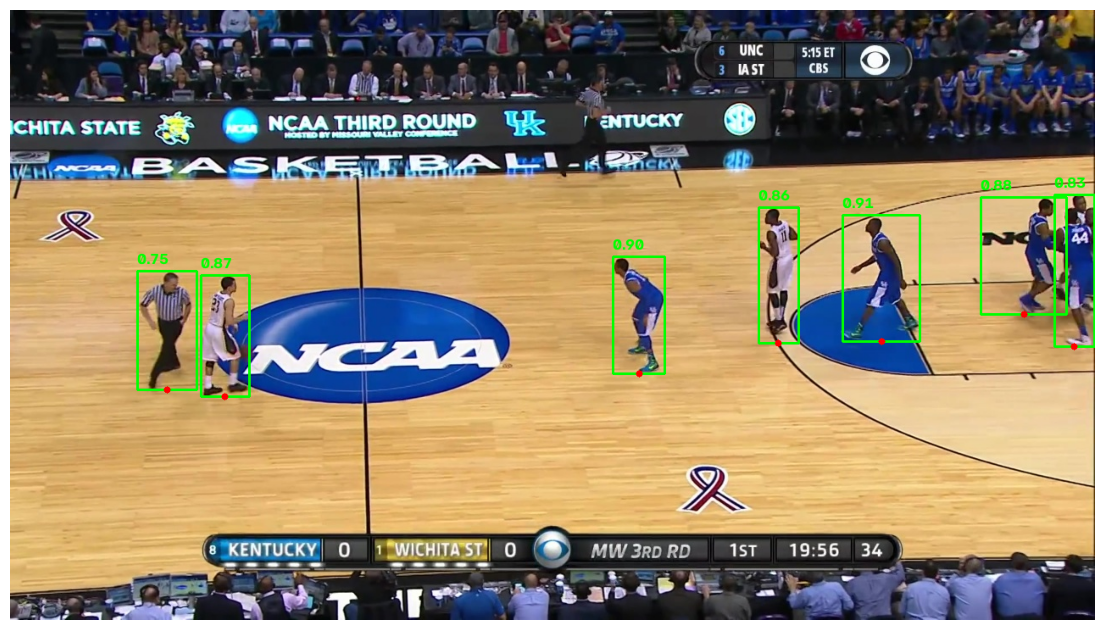

In [20]:
annotated = draw_detections(
    test_frame_rgb,
    detection_objects
)

plt.figure(figsize=(14, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [21]:
def run_detector(
    frame_rgb,
    threshold=DETECTION_THRESHOLD
):
    raw_result = PLAYER_DETECTION_MODEL.predict(
        frame_rgb,
        threshold=threshold
    )

    detections_array = extract_rfdetr_detections(
        raw_result
    )

    player_array = filter_player_detections(
        detections_array
    )

    return array_to_detection_objects(
        player_array
    )

In [22]:
detections_test = run_detector(
    test_frame_rgb
)

print(
    "Players detected:",
    len(detections_test)
)

Players detected: 7


In [23]:
BENCHMARK_FRAMES = 100

detector_times = []
detector_counts = []

for frame_path in tqdm(
    frame_paths[:BENCHMARK_FRAMES]
):
    frame = cv2.imread(
        str(frame_path)
    )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    start = time.perf_counter()

    detections_frame = run_detector(
        frame_rgb
    )

    elapsed = time.perf_counter() - start

    detector_times.append(elapsed)
    detector_counts.append(
        len(detections_frame)
    )

  0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
mean_detector_time = np.mean(
    detector_times
)

median_detector_time = np.median(
    detector_times
)

fps_detector = (
    1.0 / mean_detector_time
)

print(
    f"Mean detection time: "
    f"{mean_detector_time:.4f} s/frame"
)

print(
    f"Median detection time: "
    f"{median_detector_time:.4f} s/frame"
)

print(
    f"Estimated detector FPS: "
    f"{fps_detector:.2f}"
)

print(
    f"Average players detected: "
    f"{np.mean(detector_counts):.2f}"
)

Mean detection time: 0.0833 s/frame
Median detection time: 0.0825 s/frame
Estimated detector FPS: 12.00
Average players detected: 9.05


In [25]:
detector_benchmark_df = pd.DataFrame(
    {
        "frame": np.arange(
            1,
            BENCHMARK_FRAMES + 1
        ),
        "inference_time_s": detector_times,
        "num_players": detector_counts
    }
)

detector_benchmark_df.head()

,frame,inference_time_s,num_players
0,1,0.098517,8
1,2,0.087080,8
2,3,0.089945,9
3,4,0.089561,9
4,5,0.101211,10


In [26]:
DETECTOR_BENCHMARK_PATH = (
    OUTPUT_DIR
    / "detector_benchmark.csv"
)

detector_benchmark_df.to_csv(
    DETECTOR_BENCHMARK_PATH,
    index=False
)

print(
    "Saved:",
    DETECTOR_BENCHMARK_PATH
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/detector_benchmark.csv


In [27]:
def bbox_iou(box_a, box_b):
    """
    Compute Intersection over Union between two boxes.

    Boxes format:
    [x1, y1, x2, y2]
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)

    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)

    intersection = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - intersection

    if union <= 0:
        return 0.0

    return intersection / union

In [28]:
box_a = np.array([100, 100, 200, 300])
box_b = np.array([120, 120, 220, 320])

print("IoU overlapping boxes:", bbox_iou(box_a, box_b))

box_c = np.array([400, 400, 500, 500])

print("IoU distant boxes:", bbox_iou(box_a, box_c))

IoU overlapping boxes: 0.5625
IoU distant boxes: 0.0


In [29]:
def center_distance(box_a, box_b):
    """
    Euclidean distance between bounding-box centers.
    """

    center_a = np.array([
        (box_a[0] + box_a[2]) / 2.0,
        (box_a[1] + box_a[3]) / 2.0
    ])

    center_b = np.array([
        (box_b[0] + box_b[2]) / 2.0,
        (box_b[1] + box_b[3]) / 2.0
    ])

    return np.linalg.norm(center_a - center_b)

In [30]:
print(
    "Distance A-B:",
    center_distance(box_a, box_b)
)

print(
    "Distance A-C:",
    center_distance(box_a, box_c)
)

Distance A-B: 28.284271247461902
Distance A-C: 390.51248379533274


In [31]:
def normalized_center_distance(box_a, box_b):
    """
    Center distance normalized by the average bounding-box diagonal.
    """

    distance = center_distance(box_a, box_b)

    width_a = box_a[2] - box_a[0]
    height_a = box_a[3] - box_a[1]

    width_b = box_b[2] - box_b[0]
    height_b = box_b[3] - box_b[1]

    diagonal_a = np.sqrt(
        width_a ** 2 + height_a ** 2
    )

    diagonal_b = np.sqrt(
        width_b ** 2 + height_b ** 2
    )

    mean_diagonal = (
        diagonal_a + diagonal_b
    ) / 2.0

    if mean_diagonal <= 0:
        return np.inf

    return distance / mean_diagonal

In [32]:
def geometric_cost(
    box_track,
    box_detection,
    iou_weight=0.6,
    distance_weight=0.4
):
    """
    Lower cost = better geometric match.
    """

    iou = bbox_iou(
        box_track,
        box_detection
    )

    distance = normalized_center_distance(
        box_track,
        box_detection
    )

    iou_cost = 1.0 - iou

    distance_cost = min(
        distance,
        2.0
    ) / 2.0

    total_cost = (
        iou_weight * iou_cost
        +
        distance_weight * distance_cost
    )

    return total_cost

In [33]:
frame_100 = cv2.imread(
    str(frame_paths[99])
)

frame_101 = cv2.imread(
    str(frame_paths[100])
)

frame_100_rgb = cv2.cvtColor(
    frame_100,
    cv2.COLOR_BGR2RGB
)

frame_101_rgb = cv2.cvtColor(
    frame_101,
    cv2.COLOR_BGR2RGB
)

detections_100 = run_detector(
    frame_100_rgb
)

detections_101 = run_detector(
    frame_101_rgb
)

print(
    "Frame 100:",
    len(detections_100),
    "players"
)

print(
    "Frame 101:",
    len(detections_101),
    "players"
)

Frame 100: 7 players
Frame 101: 7 players


In [34]:
def build_geometric_cost_matrix(
    previous_detections,
    current_detections
):
    cost_matrix = np.zeros(
        (
            len(previous_detections),
            len(current_detections)
        ),
        dtype=np.float32
    )

    for i, previous in enumerate(
        previous_detections
    ):
        for j, current in enumerate(
            current_detections
        ):
            cost_matrix[i, j] = (
                geometric_cost(
                    previous.bbox,
                    current.bbox
                )
            )

    return cost_matrix

In [35]:
cost_matrix = build_geometric_cost_matrix(
    detections_100,
    detections_101
)

print(
    "Cost matrix shape:",
    cost_matrix.shape
)

print(
    np.round(
        cost_matrix,
        2
    )
)

Cost matrix shape: (7, 7)
[[0.97 1.   0.1  0.75 0.86 0.83 1.  ]
 [0.17 1.   0.96 0.82 1.   1.   1.  ]
 [1.   1.   0.81 0.95 0.6  0.28 1.  ]
 [1.   0.14 1.   1.   1.   1.   0.7 ]
 [0.83 1.   0.74 0.05 1.   0.99 1.  ]
 [1.   1.   0.86 1.   0.1  0.58 1.  ]
 [1.   0.68 1.   1.   1.   1.   0.23]]


In [36]:
for previous_index in range(
    len(detections_100)
):
    best_current_index = np.argmin(
        cost_matrix[previous_index]
    )

    best_cost = cost_matrix[
        previous_index,
        best_current_index
    ]

    print(
        f"Previous {previous_index}"
        f" -> Current {best_current_index}"
        f" | cost = {best_cost:.3f}"
    )

Previous 0 -> Current 2 | cost = 0.101
Previous 1 -> Current 0 | cost = 0.174
Previous 2 -> Current 5 | cost = 0.276
Previous 3 -> Current 1 | cost = 0.141
Previous 4 -> Current 3 | cost = 0.047
Previous 5 -> Current 4 | cost = 0.096
Previous 6 -> Current 6 | cost = 0.227


In [37]:
from scipy.optimize import linear_sum_assignment
def hungarian_assignment(cost_matrix):
    """
    Solve the global minimum-cost assignment problem.

    Returns:
        matches: list of (previous_index, current_index, cost)
    """

    if cost_matrix.size == 0:
        return []

    row_indices, col_indices = linear_sum_assignment(
        cost_matrix
    )

    matches = []

    for row, col in zip(
        row_indices,
        col_indices
    ):
        matches.append(
            (
                int(row),
                int(col),
                float(cost_matrix[row, col])
            )
        )

    return matches

In [38]:
matches = hungarian_assignment(
    cost_matrix
)

for previous_idx, current_idx, cost in matches:
    print(
        f"Previous {previous_idx}"
        f" -> Current {current_idx}"
        f" | cost = {cost:.3f}"
    )

Previous 0 -> Current 2 | cost = 0.101
Previous 1 -> Current 0 | cost = 0.174
Previous 2 -> Current 5 | cost = 0.276
Previous 3 -> Current 1 | cost = 0.141
Previous 4 -> Current 3 | cost = 0.047
Previous 5 -> Current 4 | cost = 0.096
Previous 6 -> Current 6 | cost = 0.227


In [39]:
GEOMETRIC_MATCH_THRESHOLD = 0.45

In [40]:
def filter_matches_by_cost(
    matches,
    max_cost=GEOMETRIC_MATCH_THRESHOLD
):
    accepted = []
    rejected = []

    for match in matches:
        previous_idx, current_idx, cost = match

        if cost <= max_cost:
            accepted.append(match)
        else:
            rejected.append(match)

    return accepted, rejected

In [41]:
accepted_matches, rejected_matches = (
    filter_matches_by_cost(matches)
)

print("Accepted matches:")
for match in accepted_matches:
    print(match)

print()

print("Rejected matches:")
for match in rejected_matches:
    print(match)

Accepted matches:
(0, 2, 0.10122668743133545)
(1, 0, 0.17426514625549316)
(2, 5, 0.2757210433483124)
(3, 1, 0.14126822352409363)
(4, 3, 0.04661373049020767)
(5, 4, 0.09562455117702484)
(6, 6, 0.22740447521209717)

Rejected matches:


In [42]:
def find_unmatched_indices(
    num_previous,
    num_current,
    accepted_matches
):
    matched_previous = {
        previous_idx
        for previous_idx, _, _ in accepted_matches
    }

    matched_current = {
        current_idx
        for _, current_idx, _ in accepted_matches
    }

    unmatched_previous = [
        i
        for i in range(num_previous)
        if i not in matched_previous
    ]

    unmatched_current = [
        i
        for i in range(num_current)
        if i not in matched_current
    ]

    return (
        unmatched_previous,
        unmatched_current
    )

In [43]:
unmatched_previous, unmatched_current = (
    find_unmatched_indices(
        len(detections_100),
        len(detections_101),
        accepted_matches
    )
)

print(
    "Unmatched previous:",
    unmatched_previous
)

print(
    "Unmatched current:",
    unmatched_current
)

Unmatched previous: []
Unmatched current: []


In [44]:
def draw_matches(
    previous_frame,
    current_frame,
    previous_detections,
    current_detections,
    matches
):
    prev_img = previous_frame.copy()
    curr_img = current_frame.copy()

    for previous_idx, current_idx, cost in matches:

        prev_det = previous_detections[
            previous_idx
        ]

        curr_det = current_detections[
            current_idx
        ]

        px1, py1, px2, py2 = (
            prev_det.bbox.astype(int)
        )

        cx1, cy1, cx2, cy2 = (
            curr_det.bbox.astype(int)
        )

        cv2.rectangle(
            prev_img,
            (px1, py1),
            (px2, py2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            prev_img,
            f"P{previous_idx}",
            (px1, max(py1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        cv2.rectangle(
            curr_img,
            (cx1, cy1),
            (cx2, cy2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            curr_img,
            f"P{previous_idx} {cost:.2f}",
            (cx1, max(cy1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    return prev_img, curr_img

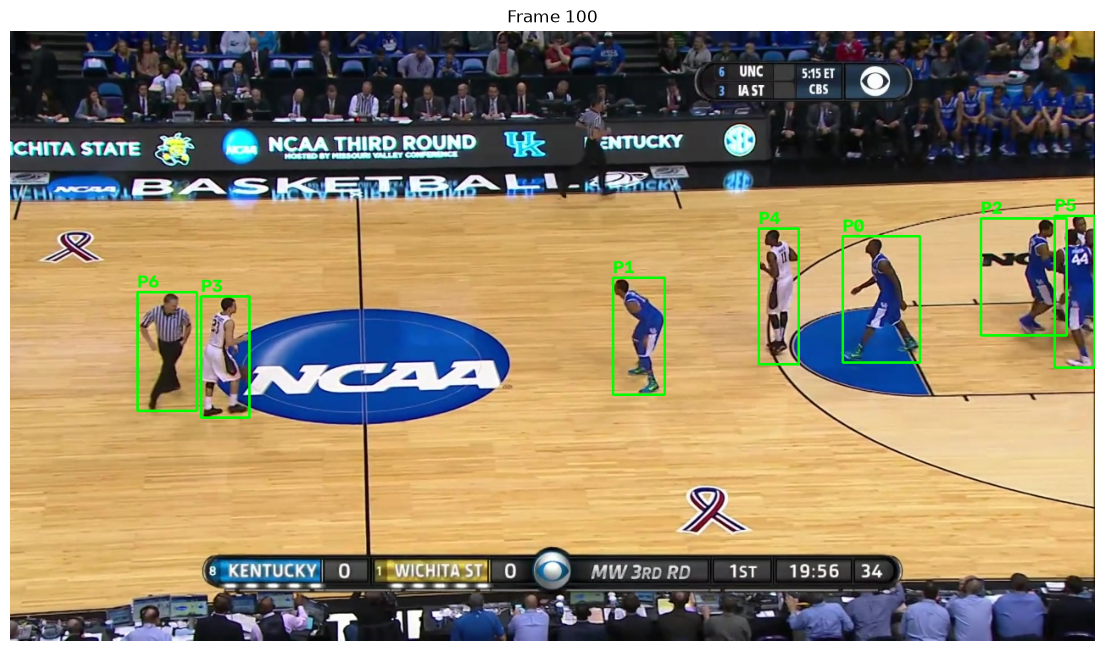

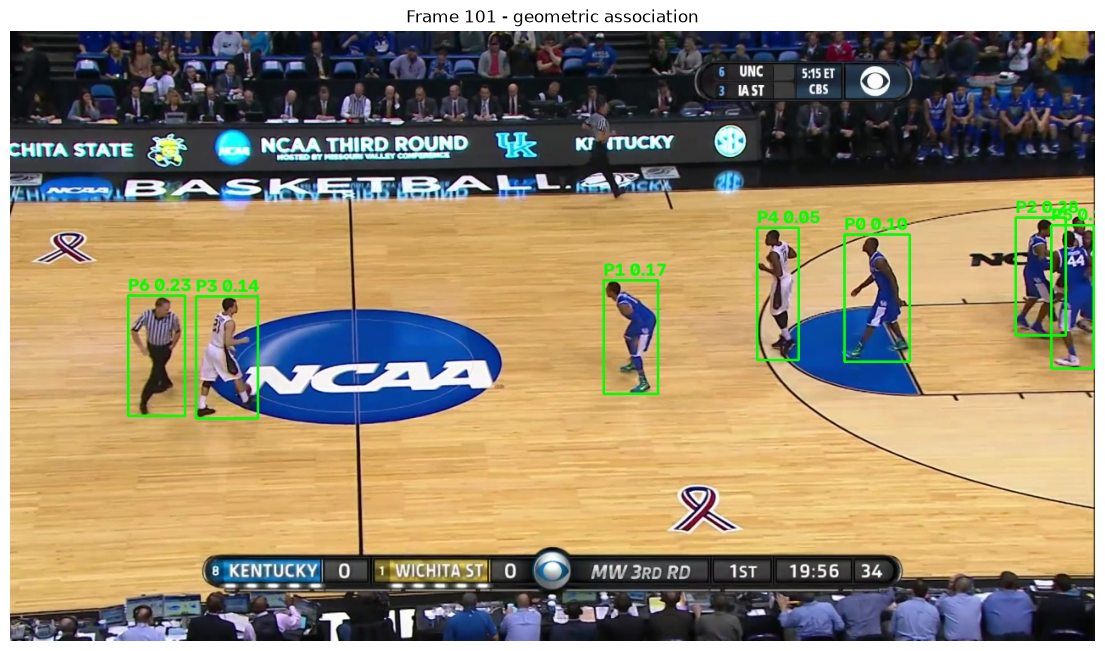

In [45]:
matched_frame_100, matched_frame_101 = (
    draw_matches(
        frame_100_rgb,
        frame_101_rgb,
        detections_100,
        detections_101,
        accepted_matches
    )
)

plt.figure(figsize=(14, 8))
plt.imshow(matched_frame_100)
plt.title("Frame 100")
plt.axis("off")
plt.show()

plt.figure(figsize=(14, 8))
plt.imshow(matched_frame_101)
plt.title("Frame 101 - geometric association")
plt.axis("off")
plt.show()

In [46]:
class KalmanFilter2D:

    def __init__(self, x, y):

        self.state = np.array(
            [
                [x],
                [y],
                [0.0],
                [0.0]
            ],
            dtype=np.float32
        )

        self.F = np.array(
            [
                [1, 0, 1, 0],
                [0, 1, 0, 1],
                [0, 0, 1, 0],
                [0, 0, 0, 1]
            ],
            dtype=np.float32
        )

        self.H = np.array(
            [
                [1, 0, 0, 0],
                [0, 1, 0, 0]
            ],
            dtype=np.float32
        )

        self.P = np.eye(
            4,
            dtype=np.float32
        ) * 10.0

        self.Q = np.eye(
            4,
            dtype=np.float32
        ) * 0.01

        self.R = np.eye(
            2,
            dtype=np.float32
        ) * 1.0

In [47]:
class KalmanFilter2D:

    def __init__(self, x, y):

        self.state = np.array(
            [
                [x],
                [y],
                [0.0],
                [0.0]
            ],
            dtype=np.float32
        )

        self.F = np.array(
            [
                [1, 0, 1, 0],
                [0, 1, 0, 1],
                [0, 0, 1, 0],
                [0, 0, 0, 1]
            ],
            dtype=np.float32
        )

        self.H = np.array(
            [
                [1, 0, 0, 0],
                [0, 1, 0, 0]
            ],
            dtype=np.float32
        )

        self.P = (
            np.eye(4, dtype=np.float32)
            * 10.0
        )

        self.Q = (
            np.eye(4, dtype=np.float32)
            * 0.01
        )

        self.R = (
            np.eye(2, dtype=np.float32)
            * 1.0
        )

    def predict(self):

        self.state = (
            self.F @ self.state
        )

        self.P = (
            self.F
            @ self.P
            @ self.F.T
            + self.Q
        )

        return self.position

    def update(self, x, y):

        measurement = np.array(
            [
                [x],
                [y]
            ],
            dtype=np.float32
        )

        innovation = (
            measurement
            - self.H @ self.state
        )

        S = (
            self.H
            @ self.P
            @ self.H.T
            + self.R
        )

        K = (
            self.P
            @ self.H.T
            @ np.linalg.inv(S)
        )

        self.state = (
            self.state
            + K @ innovation
        )

        I = np.eye(
            4,
            dtype=np.float32
        )

        self.P = (
            (I - K @ self.H)
            @ self.P
        )

        return self.position

    @property
    def position(self):

        return np.array(
            [
                self.state[0, 0],
                self.state[1, 0]
            ],
            dtype=np.float32
        )

    @property
    def velocity(self):

        return np.array(
            [
                self.state[2, 0],
                self.state[3, 0]
            ],
            dtype=np.float32
        )

In [48]:
kf = KalmanFilter2D(
    x=100,
    y=100
)

measurements = [
    (100, 100),
    (110, 100),
    (120, 100),
    (130, 100),
    (140, 100)
]

for x, y in measurements:

    predicted = kf.predict()

    corrected = kf.update(
        x,
        y
    )

    print(
        "measurement:",
        (x, y),
        "| predicted:",
        np.round(predicted, 2),
        "| corrected:",
        np.round(corrected, 2),
        "| velocity:",
        np.round(kf.velocity, 2)
    )

measurement: (100, 100) | predicted: [100. 100.] | corrected: [100. 100.] | velocity: [0. 0.]
measurement: (110, 100) | predicted: [100. 100.] | corrected: [108.78 100.  ] | velocity: [7.01 0.  ]
measurement: (120, 100) | predicted: [115.79 100.  ] | corrected: [119.07 100.  ] | velocity: [8.82 0.  ]
measurement: (130, 100) | predicted: [127.89 100.  ] | corrected: [129.31 100.  ] | velocity: [9.4 0. ]
measurement: (140, 100) | predicted: [138.72 100.  ] | corrected: [139.47 100.  ] | velocity: [9.65 0.  ]


In [49]:
class Track:

    def __init__(
        self,
        track_id,
        detection,
        frame_number
    ):
        self.track_id = track_id

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        center = detection.center

        self.kalman = KalmanFilter2D(
            center[0],
            center[1]
        )

        self.age = 1
        self.hits = 1
        self.missed_frames = 0

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.is_confirmed = False

        self.history = [
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        ]

In [50]:
class Track:

    def __init__(
        self,
        track_id,
        detection,
        frame_number
    ):
        self.track_id = track_id

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        center = detection.center

        self.kalman = KalmanFilter2D(
            center[0],
            center[1]
        )

        self.age = 1
        self.hits = 1
        self.missed_frames = 0

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.is_confirmed = False

        self.history = [
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        ]

    def predict(self):
        """
        Predict the track center in the next frame.
        """

        predicted_center = self.kalman.predict()

        return predicted_center

In [51]:
class Track:

    def __init__(
        self,
        track_id,
        detection,
        frame_number
    ):
        self.track_id = track_id

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        center = detection.center

        self.kalman = KalmanFilter2D(
            center[0],
            center[1]
        )

        self.age = 1
        self.hits = 1
        self.missed_frames = 0

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.is_confirmed = False

        self.history = [
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        ]

    def predict(self):

        return self.kalman.predict()

    def update(
        self,
        detection,
        frame_number
    ):
        center = detection.center

        self.kalman.update(
            center[0],
            center[1]
        )

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        self.age += 1
        self.hits += 1

        self.missed_frames = 0
        self.last_frame = frame_number

        self.history.append(
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        )

In [52]:
    def mark_missed(self):
        self.age += 1
        self.missed_frames += 1

In [53]:
class Track:

    def __init__(
        self,
        track_id,
        detection,
        frame_number
    ):
        self.track_id = track_id

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        center = detection.center

        self.kalman = KalmanFilter2D(
            center[0],
            center[1]
        )

        self.age = 1
        self.hits = 1
        self.missed_frames = 0

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.is_confirmed = False

        self.history = [
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        ]

    def predict(self):
        return self.kalman.predict()

    def update(
        self,
        detection,
        frame_number
    ):
        center = detection.center

        self.kalman.update(
            center[0],
            center[1]
        )

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        self.age += 1
        self.hits += 1

        self.missed_frames = 0
        self.last_frame = frame_number

        self.history.append(
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        )

    def mark_missed(self):
        self.age += 1
        self.missed_frames += 1

In [54]:
def predicted_bbox(track):
    """
    Move the current bounding box so that its center
    corresponds to the Kalman-predicted center.
    """

    predicted_center = track.kalman.position

    x1, y1, x2, y2 = track.bbox

    width = x2 - x1
    height = y2 - y1

    cx, cy = predicted_center

    return np.array(
        [
            cx - width / 2,
            cy - height / 2,
            cx + width / 2,
            cy + height / 2
        ],
        dtype=np.float32
    )

In [55]:
tracks = []

for track_id, detection in enumerate(
    detections_100
):
    track = Track(
        track_id=track_id,
        detection=detection,
        frame_number=100
    )

    tracks.append(track)

print(
    "Tracks created:",
    len(tracks)
)

for track in tracks:
    print(
        "ID:",
        track.track_id,
        "| bbox:",
        np.round(track.bbox, 1),
        "| center:",
        np.round(
            track.kalman.position,
            1
        )
    )

Tracks created: 7
ID: 0 | bbox: [ 982.8  242.7 1073.9  391. ] | center: [1028.4  316.9]
ID: 1 | bbox: [711.1 291.9 772.9 429.4] | center: [742.  360.6]
ID: 2 | bbox: [1145.9  221.4 1246.9  359. ] | center: [1196.4  290.2]
ID: 3 | bbox: [225.4 313.3 282.3 456.7] | center: [253.8 385. ]
ID: 4 | bbox: [883.4 233.  930.4 393.3] | center: [906.9 313.2]
ID: 5 | bbox: [1232.3  218.4 1279.7  397.9] | center: [1256.   308.1]
ID: 6 | bbox: [150.9 308.8 220.7 448.9] | center: [185.8 378.9]


In [56]:
for track in tracks:
    predicted_center = track.predict()

    print(
        f"Track {track.track_id}"
        f" predicted center:"
        f" {np.round(predicted_center, 1)}"
    )

Track 0 predicted center: [1028.4  316.9]
Track 1 predicted center: [742.  360.6]
Track 2 predicted center: [1196.4  290.2]
Track 3 predicted center: [253.8 385. ]
Track 4 predicted center: [906.9 313.2]
Track 5 predicted center: [1256.   308.1]
Track 6 predicted center: [185.8 378.9]


In [57]:
def build_track_detection_cost_matrix(
    tracks,
    detections
):
    cost_matrix = np.zeros(
        (
            len(tracks),
            len(detections)
        ),
        dtype=np.float32
    )

    for i, track in enumerate(tracks):

        track_box = predicted_bbox(track)

        for j, detection in enumerate(
            detections
        ):
            cost_matrix[i, j] = (
                geometric_cost(
                    track_box,
                    detection.bbox
                )
            )

    return cost_matrix

In [58]:
track_cost_matrix = (
    build_track_detection_cost_matrix(
        tracks,
        detections_101
    )
)

print(
    np.round(
        track_cost_matrix,
        2
    )
)

[[0.97 1.   0.1  0.75 0.86 0.83 1.  ]
 [0.17 1.   0.96 0.82 1.   1.   1.  ]
 [1.   1.   0.81 0.95 0.6  0.28 1.  ]
 [1.   0.14 1.   1.   1.   1.   0.7 ]
 [0.83 1.   0.74 0.05 1.   0.99 1.  ]
 [1.   1.   0.86 1.   0.1  0.58 1.  ]
 [1.   0.68 1.   1.   1.   1.   0.23]]


In [59]:
track_matches = hungarian_assignment(
    track_cost_matrix
)

accepted_track_matches, rejected_track_matches = (
    filter_matches_by_cost(
        track_matches
    )
)

for track_idx, detection_idx, cost in accepted_track_matches:
    print(
        f"Track {tracks[track_idx].track_id}"
        f" -> Detection {detection_idx}"
        f" | cost = {cost:.3f}"
    )

Track 0 -> Detection 2 | cost = 0.101
Track 1 -> Detection 0 | cost = 0.174
Track 2 -> Detection 5 | cost = 0.276
Track 3 -> Detection 1 | cost = 0.141
Track 4 -> Detection 3 | cost = 0.047
Track 5 -> Detection 4 | cost = 0.096
Track 6 -> Detection 6 | cost = 0.227


In [60]:
matched_track_indices = set()
matched_detection_indices = set()

for (
    track_idx,
    detection_idx,
    cost
) in accepted_track_matches:

    track = tracks[track_idx]

    detection = detections_101[
        detection_idx
    ]

    track.update(
        detection,
        frame_number=101
    )

    matched_track_indices.add(
        track_idx
    )

    matched_detection_indices.add(
        detection_idx
    )

In [61]:
for track in tracks:
    print(
        f"Track {track.track_id}"
        f" | hits={track.hits}"
        f" | missed={track.missed_frames}"
        f" | velocity="
        f"{np.round(track.kalman.velocity, 2)}"
    )

Track 0 | hits=2 | missed=0 | velocity=[-2.56 -0.51]
Track 1 | hits=2 | missed=0 | velocity=[-4.4  0.5]
Track 2 | hits=2 | missed=0 | velocity=[ 9.17 -0.08]
Track 3 | hits=2 | missed=0 | velocity=[1.02 0.24]
Track 4 | hits=2 | missed=0 | velocity=[-0.5 -1.2]
Track 5 | hits=2 | missed=0 | velocity=[-1.14  2.78]
Track 6 | hits=2 | missed=0 | velocity=[-6.06  2.18]


In [62]:
MAX_MISSED_FRAMES = 10
MIN_HITS_TO_CONFIRM = 3

print("MAX_MISSED_FRAMES:", MAX_MISSED_FRAMES)
print("MIN_HITS_TO_CONFIRM:", MIN_HITS_TO_CONFIRM)

MAX_MISSED_FRAMES: 10
MIN_HITS_TO_CONFIRM: 3


In [63]:
class Track:

    def __init__(
        self,
        track_id,
        detection,
        frame_number
    ):
        self.track_id = track_id

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        center = detection.center

        self.kalman = KalmanFilter2D(
            center[0],
            center[1]
        )

        self.age = 1
        self.hits = 1
        self.missed_frames = 0

        self.first_frame = frame_number
        self.last_frame = frame_number

        self.is_confirmed = False

        self.history = [
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        ]

    def predict(self):
        """
        Advance the Kalman state by one frame.
        """
        return self.kalman.predict()

    def update(
        self,
        detection,
        frame_number
    ):
        center = detection.center

        self.kalman.update(
            center[0],
            center[1]
        )

        self.bbox = detection.bbox.copy()
        self.confidence = detection.confidence

        self.age += 1
        self.hits += 1

        self.missed_frames = 0
        self.last_frame = frame_number

        if self.hits >= MIN_HITS_TO_CONFIRM:
            self.is_confirmed = True

        self.history.append(
            {
                "frame": frame_number,
                "bbox": self.bbox.copy(),
                "center": center.copy(),
                "confidence": detection.confidence
            }
        )

    def mark_missed(self):
        self.age += 1
        self.missed_frames += 1

    @property
    def predicted_bbox(self):
        """
        Bounding box centered on the current Kalman prediction,
        while preserving the last observed width and height.
        """

        cx, cy = self.kalman.position

        x1, y1, x2, y2 = self.bbox

        width = x2 - x1
        height = y2 - y1

        return np.array(
            [
                cx - width / 2,
                cy - height / 2,
                cx + width / 2,
                cy + height / 2
            ],
            dtype=np.float32
        )

    @property
    def center(self):
        return self.kalman.position

In [64]:
def build_track_detection_cost_matrix(
    tracks,
    detections
):
    cost_matrix = np.zeros(
        (
            len(tracks),
            len(detections)
        ),
        dtype=np.float32
    )

    for i, track in enumerate(tracks):

        track_box = track.predicted_bbox

        for j, detection in enumerate(detections):

            cost_matrix[i, j] = geometric_cost(
                track_box,
                detection.bbox
            )

    return cost_matrix

In [65]:
def associate_tracks_and_detections(
    tracks,
    detections,
    max_cost=GEOMETRIC_MATCH_THRESHOLD
):
    """
    Associate active tracks with current detections.

    Returns:
        accepted_matches
        unmatched_track_indices
        unmatched_detection_indices
        cost_matrix
    """

    if len(tracks) == 0:
        return (
            [],
            [],
            list(range(len(detections))),
            np.empty((0, len(detections)))
        )

    if len(detections) == 0:
        return (
            [],
            list(range(len(tracks))),
            [],
            np.empty((len(tracks), 0))
        )

    cost_matrix = (
        build_track_detection_cost_matrix(
            tracks,
            detections
        )
    )

    raw_matches = hungarian_assignment(
        cost_matrix
    )

    accepted_matches, rejected_matches = (
        filter_matches_by_cost(
            raw_matches,
            max_cost=max_cost
        )
    )

    matched_tracks = {
        track_idx
        for track_idx, _, _ in accepted_matches
    }

    matched_detections = {
        detection_idx
        for _, detection_idx, _ in accepted_matches
    }

    unmatched_tracks = [
        i
        for i in range(len(tracks))
        if i not in matched_tracks
    ]

    unmatched_detections = [
        i
        for i in range(len(detections))
        if i not in matched_detections
    ]

    return (
        accepted_matches,
        unmatched_tracks,
        unmatched_detections,
        cost_matrix
    )

In [66]:
class SimpleTracker:

    def __init__(
        self,
        max_missed_frames=MAX_MISSED_FRAMES,
        match_threshold=GEOMETRIC_MATCH_THRESHOLD
    ):
        self.max_missed_frames = (
            max_missed_frames
        )

        self.match_threshold = (
            match_threshold
        )

        self.active_tracks = []
        self.finished_tracks = []

        self.next_track_id = 0

In [67]:
class SimpleTracker:

    def __init__(
        self,
        max_missed_frames=MAX_MISSED_FRAMES,
        match_threshold=GEOMETRIC_MATCH_THRESHOLD
    ):
        self.max_missed_frames = (
            max_missed_frames
        )

        self.match_threshold = (
            match_threshold
        )

        self.active_tracks = []
        self.finished_tracks = []

        self.next_track_id = 0

    def create_track(
        self,
        detection,
        frame_number
    ):
        track = Track(
            track_id=self.next_track_id,
            detection=detection,
            frame_number=frame_number
        )

        self.active_tracks.append(
            track
        )

        self.next_track_id += 1

        return track

In [68]:
class SimpleTracker:

    def __init__(
        self,
        max_missed_frames=MAX_MISSED_FRAMES,
        match_threshold=GEOMETRIC_MATCH_THRESHOLD
    ):
        self.max_missed_frames = (
            max_missed_frames
        )

        self.match_threshold = (
            match_threshold
        )

        self.active_tracks = []
        self.finished_tracks = []

        self.next_track_id = 0

    def create_track(
        self,
        detection,
        frame_number
    ):
        track = Track(
            track_id=self.next_track_id,
            detection=detection,
            frame_number=frame_number
        )

        self.active_tracks.append(track)

        self.next_track_id += 1

        return track

    def update(
        self,
        detections,
        frame_number
    ):

        # ----------------------------------
        # 1. First frame / no active tracks
        # ----------------------------------

        if len(self.active_tracks) == 0:

            for detection in detections:
                self.create_track(
                    detection,
                    frame_number
                )

            return {
                "matches": [],
                "unmatched_tracks": [],
                "unmatched_detections":
                    list(range(len(detections))),
                "new_tracks": len(detections)
            }

        # ----------------------------------
        # 2. Kalman prediction
        # ----------------------------------

        for track in self.active_tracks:
            track.predict()

        # ----------------------------------
        # 3. Geometric association
        # ----------------------------------

        (
            matches,
            unmatched_track_indices,
            unmatched_detection_indices,
            cost_matrix
        ) = associate_tracks_and_detections(
            self.active_tracks,
            detections,
            max_cost=self.match_threshold
        )

        # ----------------------------------
        # 4. Update matched tracks
        # ----------------------------------

        for (
            track_idx,
            detection_idx,
            cost
        ) in matches:

            self.active_tracks[
                track_idx
            ].update(
                detections[detection_idx],
                frame_number
            )

        # ----------------------------------
        # 5. Mark unmatched tracks
        # ----------------------------------

        for track_idx in unmatched_track_indices:

            self.active_tracks[
                track_idx
            ].mark_missed()

        # ----------------------------------
        # 6. New tracks for unmatched detections
        # ----------------------------------

        new_track_count = 0

        for detection_idx in (
            unmatched_detection_indices
        ):

            self.create_track(
                detections[detection_idx],
                frame_number
            )

            new_track_count += 1

        # ----------------------------------
        # 7. Remove expired tracks
        # ----------------------------------

        still_active = []

        for track in self.active_tracks:

            if (
                track.missed_frames
                > self.max_missed_frames
            ):
                self.finished_tracks.append(
                    track
                )
            else:
                still_active.append(track)

        self.active_tracks = still_active

        return {
            "matches": matches,
            "unmatched_tracks":
                unmatched_track_indices,
            "unmatched_detections":
                unmatched_detection_indices,
            "new_tracks":
                new_track_count,
            "cost_matrix":
                cost_matrix
        }

In [69]:
START_FRAME = 100
END_FRAME = 130

tracker = SimpleTracker()

tracking_debug = []

In [70]:
for frame_number in tqdm(
    range(
        START_FRAME,
        END_FRAME + 1
    )
):

    frame_path = frame_paths[
        frame_number - 1
    ]

    frame = cv2.imread(
        str(frame_path)
    )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections_frame = run_detector(
        frame_rgb
    )

    result_update = tracker.update(
        detections_frame,
        frame_number
    )

    tracking_debug.append(
        {
            "frame": frame_number,
            "detections":
                len(detections_frame),
            "active_tracks":
                len(tracker.active_tracks),
            "total_ids_created":
                tracker.next_track_id,
            "new_tracks":
                result_update["new_tracks"],
            "unmatched_tracks":
                len(
                    result_update[
                        "unmatched_tracks"
                    ]
                ),
            "unmatched_detections":
                len(
                    result_update[
                        "unmatched_detections"
                    ]
                )
        }
    )

  0%|          | 0/31 [00:00<?, ?it/s]

In [71]:
tracking_debug_df = pd.DataFrame(
    tracking_debug
)

tracking_debug_df

,frame,detections,active_tracks,total_ids_created,new_tracks,unmatched_tracks,unmatched_detections
0,100,7,7,7,7,0,7
1,101,7,7,7,0,0,0
2,102,9,9,9,2,0,2
3,103,9,9,9,0,0,0
4,104,9,9,9,0,0,0
5,105,8,9,9,0,1,0
6,106,7,9,9,0,2,0
7,107,9,10,10,1,1,1
8,108,7,10,10,0,3,0
9,109,8,10,10,0,2,0


In [72]:
def draw_tracks(
    frame_rgb,
    tracks
):
    output = frame_rgb.copy()

    for track in tracks:

        # Disegniamo solo le track attualmente visibili
        if track.missed_frames > 0:
            continue

        x1, y1, x2, y2 = (
            track.bbox.astype(int)
        )

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = f"ID {track.track_id}"

        cv2.putText(
            output,
            label,
            (
                x1,
                max(y1 - 8, 0)
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    return output

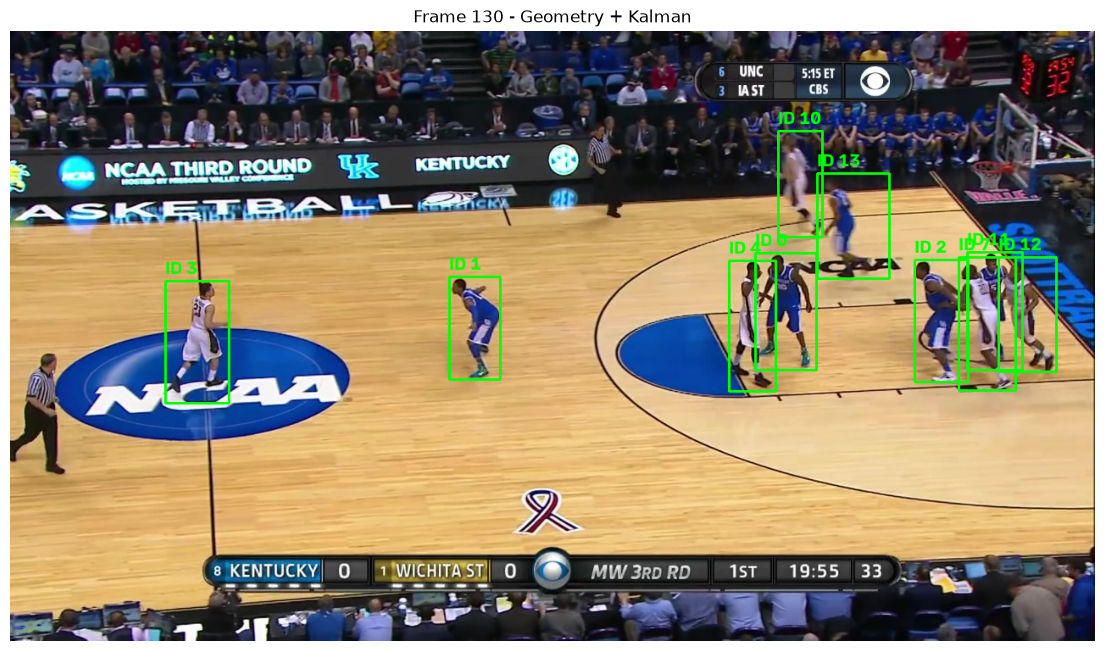

In [73]:
final_frame_path = frame_paths[
    END_FRAME - 1
]

final_frame = cv2.imread(
    str(final_frame_path)
)

final_frame_rgb = cv2.cvtColor(
    final_frame,
    cv2.COLOR_BGR2RGB
)

annotated_final = draw_tracks(
    final_frame_rgb,
    tracker.active_tracks
)

plt.figure(figsize=(14, 8))
plt.imshow(annotated_final)

plt.title(
    f"Frame {END_FRAME} - Geometry + Kalman"
)

plt.axis("off")
plt.show()

In [74]:
# Re-ID configuration

MAX_GALLERY_SIZE = 3

# These thresholds are provisional.
# We will calibrate them experimentally.
REID_STRONG_MATCH_THRESHOLD = 0.80
REID_AMBIGUOUS_THRESHOLD = 0.65
REID_MARGIN_THRESHOLD = 0.08

print("Max gallery size:", MAX_GALLERY_SIZE)
print("Strong match threshold:", REID_STRONG_MATCH_THRESHOLD)
print("Ambiguous threshold:", REID_AMBIGUOUS_THRESHOLD)

Max gallery size: 3
Strong match threshold: 0.8
Ambiguous threshold: 0.65


In [75]:
import boxmot

print("BoxMOT loaded.")
print("BoxMOT module:", boxmot)

BoxMOT loaded.
BoxMOT module: <module 'boxmot' from '/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/boxmot/__init__.py'>


In [76]:
REID_DIR = (
    DRIVE_ROOT
    / "checkpoints"
    / "reid"
)

REID_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REID_WEIGHTS = (
    REID_DIR
    / "osnet_x0_25_msmt17.pt"
)

print("Re-ID weights:")
print(REID_WEIGHTS)

print(
    "Weights already available:",
    REID_WEIGHTS.exists()
)

Re-ID weights:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/checkpoints/reid/osnet_x0_25_msmt17.pt
Weights already available: False


In [77]:
import boxmot

print("BoxMOT version:", boxmot.__version__)

BoxMOT version: 25.0.0


In [78]:
import boxmot

print("BoxMOT version:", getattr(boxmot, "__version__", "unknown"))
print()
print("Available symbols:")
print(sorted(dir(boxmot)))

BoxMOT version: 25.0.0

Available symbols:
['BoostTrack', 'BotSort', 'ByteTrack', 'DeepOcSort', 'HybridSort', 'OcSort', 'OccluBoost', 'SFSORT', 'Sam2Mot', 'StrongSort', 'TYPE_CHECKING', '_EXPORTS', '_TRACKER_EXPORTS', '__all__', '__builtins__', '__cached__', '__dir__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_tracker_exports', 'create_tracker', 'import_module']


In [79]:
import pkgutil
import boxmot

reid_modules = []

for module in pkgutil.walk_packages(
    boxmot.__path__,
    prefix="boxmot."
):
    name = module.name.lower()

    if (
        "reid" in name
        or "appearance" in name
        or "osnet" in name
    ):
        reid_modules.append(module.name)

print("Re-ID related modules:")
for module_name in reid_modules:
    print(module_name)

Re-ID related modules:
boxmot.engine.commands.reid
boxmot.engine.commands.reid._options
boxmot.engine.commands.reid.ablation
boxmot.engine.commands.reid.compare
boxmot.engine.commands.reid.evaluate
boxmot.engine.commands.reid.export
boxmot.engine.commands.reid.human_pretrain
boxmot.engine.commands.reid.privileged_cache
boxmot.engine.commands.reid.teacher_extract
boxmot.engine.commands.reid.train
boxmot.native.reid
boxmot.native.reid.capi
boxmot.reid
boxmot.reid.adapters
boxmot.reid.backbones
boxmot.reid.backbones.anatomical_registry
boxmot.reid.backbones.base
boxmot.reid.backbones.common
boxmot.reid.backbones.common.attention
boxmot.reid.backbones.common.init
boxmot.reid.backbones.common.pretrained
boxmot.reid.backbones.common.typing
boxmot.reid.backbones.families
boxmot.reid.backbones.families.csl_tinyvit
boxmot.reid.backbones.families.csl_tinyvit.attention
boxmot.reid.backbones.families.csl_tinyvit.blocks
boxmot.reid.backbones.families.csl_tinyvit.deployment
boxmot.reid.backbones.fam

In [80]:
import inspect
import boxmot

for name in dir(boxmot):
    if "sort" in name.lower() or "reid" in name.lower():
        obj = getattr(boxmot, name)

        print("\n---", name, "---")

        try:
            print(inspect.signature(obj))
        except Exception:
            print(type(obj))


--- BotSort ---
(track_high_thresh: 'float' = 0.5, track_low_thresh: 'float' = 0.1, new_track_thresh: 'float' = 0.6, track_buffer: 'int' = 30, match_thresh: 'float' = 0.8, proximity_thresh: 'float' = 0.5, appearance_thresh: 'float' = 0.25, use_cmc: 'bool' = True, cmc_method: 'str' = 'ecc', frame_rate: 'int' = 30, fuse_first_associate: 'bool' = False, use_embeddings: 'bool' = True, second_match_thresh: 'float' = 0.5, unconfirmed_match_thresh: 'float' = 0.7, unconfirmed_emb_scale: 'float' = 2.0, removed_stracks_buffer: 'int' = 100, *, reid_model: 'Any | None' = None, reid_weights: 'str | Path | list[str | Path] | tuple[str | Path, ...] | None' = None, device: 'Any' = 'cpu', half: 'bool' = False, reid_preprocess: 'str | None' = None, **kwargs: 'Any')

--- DeepOcSort ---
(delta_t: 'int' = 3, inertia: 'float' = 0.2, w_association_emb: 'float' = 0.5, alpha_fixed_emb: 'float' = 0.95, aw_param: 'float' = 0.5, use_embeddings: 'bool' = True, cmc_off: 'bool' = False, aw_off: 'bool' = False, *, r

In [81]:
import inspect
import boxmot.reid.factory as reid_factory

print("=== boxmot.reid.factory ===")

for name in dir(reid_factory):
    if name.startswith("_"):
        continue

    obj = getattr(reid_factory, name)

    if callable(obj):
        print(f"\n{name}")

        try:
            print("  signature:", inspect.signature(obj))
        except Exception:
            print("  type:", type(obj))

=== boxmot.reid.factory ===

AppearanceEncoder
  signature: (*args, **kwargs)

Callable
  signature: ()

EncoderRequirements
  signature: (masks: 'bool' = False) -> None

LazyComponentRegistry
  signature: (component: 'str', entries: 'Mapping[str, str]') -> None

ReIDEncoderFactory
  type: <class 'collections.abc._CallableGenericAlias'>

ReIDEncoderSpec
  signature: (backend: 'str', artifact: 'str | None' = None, artifact_sha256: 'str | None' = None, device: 'str' = 'cpu', precision: 'str' = 'fp32', options: 'tuple[tuple[str, JSONValue], ...]' = (), preprocessing: 'str' = 'default') -> None

create_reid_encoder
  signature: (spec: 'ReIDEncoderSpec') -> 'AppearanceEncoder'

require_resolved_artifact
  signature: (path: 'str | None', expected_sha256: 'str | None', *, component: 'str') -> 'Path'


In [82]:
import boxmot.reid.core.runtime as reid_runtime

print("\n=== boxmot.reid.core.runtime ===")

for name in dir(reid_runtime):
    if name.startswith("_"):
        continue

    obj = getattr(reid_runtime, name)

    if callable(obj):
        print(f"\n{name}")

        try:
            print("  signature:", inspect.signature(obj))
        except Exception:
            print("  type:", type(obj))


=== boxmot.reid.core.runtime ===

Any
  signature: (*args, **kwargs)

Path
  signature: (*args, **kwargs)

ReID
  signature: (path: 'str | Path | list[str | Path] | tuple[str | Path, ...] | None' = None, *, weights: 'str | Path | list[str | Path] | tuple[str | Path, ...] | None' = None, device: 'str | torch.device' = 'cpu', half: 'bool' = False, preprocess_name: 'str | None' = None) -> 'None'

ReIDFormat
  signature: (id: 'str', name: 'str', argument: 'str', suffix: 'str', cpu: 'bool', gpu: 'bool', alternate_suffixes: 'tuple[str, ...]' = ()) -> None

coerce_boxes
  signature: (boxes: 'Any') -> 'np.ndarray'

coerce_crops
  signature: (crops: 'Any') -> 'list[np.ndarray]'

get_backend_class
  signature: (format_: 'ReIDFormat | str') -> 'type[Any]'

get_preprocess_fn
  signature: (name: 'Optional[str]' = None) -> 'Callable'

prepare_crop_batch
  signature: (crops: 'Sequence[np.ndarray]', *, input_shape: 'tuple[int, int]', device: 'torch.device', half: 'bool', preprocess_fn: 'Callable[[np.

In [83]:
from boxmot.reid.core.runtime import ReID
import inspect

print("=== ReID methods ===")

for name in dir(ReID):
    if name.startswith("_"):
        continue

    obj = getattr(ReID, name)

    if callable(obj):
        print(f"\n{name}")

        try:
            print("  signature:", inspect.signature(obj))
        except Exception:
            print("  type:", type(obj))

=== ReID methods ===

from_backend
  signature: (backend: 'Any') -> "'ReID'"

get_backend
  signature: (self)

postprocess
  signature: (self, features, **kwargs) -> 'np.ndarray'

preprocess
  signature: (self, inputs, boxes=None, **kwargs)

process
  signature: (self, payload, **kwargs)


In [84]:
import boxmot

print(
    "ReIDModel available:",
    hasattr(boxmot, "ReIDModel")
)

ReIDModel available: False


In [85]:
import inspect
from boxmot.reid.core.runtime import ReID

print("=== ReID.__init__ ===")
print(inspect.getsource(ReID.__init__))

print("\n=== ReID.preprocess ===")
print(inspect.getsource(ReID.preprocess))

print("\n=== ReID.process ===")
print(inspect.getsource(ReID.process))

=== ReID.__init__ ===
    def __init__(
        self,
        path: str | Path | list[str | Path] | tuple[str | Path, ...] | None = None,
        *,
        weights: str | Path | list[str | Path] | tuple[str | Path, ...] | None = None,
        device: str | torch.device = "cpu",
        half: bool = False,
        preprocess_name: str | None = None,
    ) -> None:
        model_ref = path if path is not None else weights
        if model_ref is None:
            model_ref = WEIGHTS / "osnet_x0_25_msmt17.pt"

        primary_weight = model_ref[0] if isinstance(model_ref, (list, tuple)) else model_ref
        self.path = Path(primary_weight)
        self.weights = model_ref
        self.device = device if isinstance(device, torch.device) else select_device(device)
        self.half = bool(half)
        self.preprocess_name = preprocess_name or DEFAULT_PREPROCESS
        self.format = resolve_reid_format(self.path)
        self.backend = self
        self.model = self.get_backend()


=== 

In [86]:
from boxmot.reid.core.runtime import ReID

reid_model = ReID(
    device=DEVICE,
    half=(DEVICE == "cuda")
)

print("Re-ID loaded.")
print("Weights:", reid_model.path)
print("Device:", reid_model.device)
print("Backend:", type(reid_model.model))

INFO     BoxMOT v25.0.0 🚀 Python-3.11.8 torch-2.14.0MPS

INFO     /Users/marcodalbis/Desktop/Tesi                                                                           
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt

INFO     [PID 23406] Found existing ReID weights at /Users/marcodalbis/Desktop/Tesi                                
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt; skipping download.

INFO     Loaded deployed weights from /Users/marcodalbis/Desktop/Tesi                                              
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt: 565/565 required tensors, 100.00% required elements

Re-ID loaded.
Weights: /Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt17.pt
Device: mps
Backend: <class 'boxmot.reid.backends.pytorch_backend.PyTorchBackend'>


In [87]:
def extract_reid_embeddings(
    frame,
    boxes
):
    boxes = np.asarray(
        boxes,
        dtype=np.float32
    )

    payload = reid_model.preprocess(
        frame,
        boxes=boxes
    )

    raw_features = reid_model.process(
        payload
    )

    features = reid_model.postprocess(
        raw_features
    )

    return np.asarray(
        features,
        dtype=np.float32
    )

In [88]:
test_boxes = np.asarray(
    [detections_100[0].bbox],
    dtype=np.float32
)

test_embeddings = extract_reid_embeddings(
    frame_100,
    test_boxes
)

print("Embeddings shape:", test_embeddings.shape)
print("First embedding norm:", np.linalg.norm(test_embeddings[0]))

Embeddings shape: (1, 512)
First embedding norm: 0.99999994


In [89]:
def cosine_similarity(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    a = a / (np.linalg.norm(a) + 1e-12)
    b = b / (np.linalg.norm(b) + 1e-12)

    return float(np.dot(a, b))

In [90]:
boxes_100 = np.asarray(
    [det.bbox for det in detections_100],
    dtype=np.float32
)

boxes_101 = np.asarray(
    [det.bbox for det in detections_101],
    dtype=np.float32
)

embeddings_100 = extract_reid_embeddings(
    frame_100,
    boxes_100
)

embeddings_101 = extract_reid_embeddings(
    frame_101,
    boxes_101
)

reference_embedding = embeddings_100[0]

rows = []

for idx, embedding in enumerate(embeddings_101):
    rows.append({
        "detection_101": idx,
        "similarity": cosine_similarity(
            reference_embedding,
            embedding
        )
    })

reid_test_df = pd.DataFrame(rows).sort_values(
    "similarity",
    ascending=False
)

reid_test_df

,detection_101,similarity
2,2,0.969458
5,5,0.760581
0,0,0.719490
4,4,0.686738
1,1,0.675860
3,3,0.609321
6,6,0.536812


In [91]:
REID_MATCH_THRESHOLD = 0.75
REID_AMBIGUOUS_THRESHOLD = 0.60
REID_MARGIN_THRESHOLD = 0.08

GALLERY_UPDATE_INTERVAL = 15
MAX_GALLERY_SIZE = 3

COLLISION_IOU_THRESHOLD = 0.25

print("Re-ID match threshold:", REID_MATCH_THRESHOLD)
print("Re-ID ambiguous threshold:", REID_AMBIGUOUS_THRESHOLD)
print("Re-ID margin threshold:", REID_MARGIN_THRESHOLD)
print("Gallery update interval:", GALLERY_UPDATE_INTERVAL)
print("Collision IoU threshold:", COLLISION_IOU_THRESHOLD)

Re-ID match threshold: 0.75
Re-ID ambiguous threshold: 0.6
Re-ID margin threshold: 0.08
Gallery update interval: 15
Collision IoU threshold: 0.25


In [92]:
class ReIDGallery:

    def __init__(self, max_size=MAX_GALLERY_SIZE):
        self.max_size = max_size
        self.data = {}

    def add(self, track_id, embedding):

        embedding = np.asarray(
            embedding,
            dtype=np.float32
        )

        embedding /= (
            np.linalg.norm(embedding) + 1e-12
        )

        if track_id not in self.data:
            self.data[track_id] = []

        self.data[track_id].append(
            embedding
        )

        if len(self.data[track_id]) > self.max_size:
            self.data[track_id].pop(0)

    def similarity(self, track_id, embedding):

        if track_id not in self.data:
            return None

        if len(self.data[track_id]) == 0:
            return None

        scores = [
            cosine_similarity(
                reference,
                embedding
            )
            for reference
            in self.data[track_id]
        ]

        return float(max(scores))

    def size(self, track_id):
        return len(
            self.data.get(track_id, [])
        )

In [93]:
def detection_in_collision(
    detection,
    detections,
    detection_idx,
    threshold=COLLISION_IOU_THRESHOLD
):
    for other_idx, other in enumerate(detections):

        if other_idx == detection_idx:
            continue

        iou = bbox_iou(
            detection.bbox,
            other.bbox
        )

        if iou >= threshold:
            return True

    return False

In [94]:
def find_best_reid_match(
    embedding,
    candidate_tracks,
    gallery
):
    scores = []

    for track in candidate_tracks:

        similarity = gallery.similarity(
            track.track_id,
            embedding
        )

        if similarity is None:
            continue

        scores.append(
            (
                track,
                similarity
            )
        )

    if not scores:
        return {
            "decision": "no_candidates",
            "track": None,
            "best_similarity": None,
            "second_similarity": None,
            "margin": None
        }

    scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    best_track, best_similarity = scores[0]

    if len(scores) > 1:
        second_similarity = scores[1][1]
    else:
        second_similarity = -1.0

    margin = (
        best_similarity
        - second_similarity
    )

    if (
        best_similarity >= REID_MATCH_THRESHOLD
        and
        margin >= REID_MARGIN_THRESHOLD
    ):
        decision = "strong_match"

    elif (
        best_similarity >= REID_AMBIGUOUS_THRESHOLD
    ):
        decision = "ambiguous"

    else:
        decision = "no_match"

    return {
        "decision": decision,
        "track": best_track,
        "best_similarity": best_similarity,
        "second_similarity": second_similarity,
        "margin": margin
    }

In [95]:
SAM2_ENABLED = True

sam2_predictor = None
sam2_load_count = 0
sam2_call_count = 0

In [96]:
def should_use_sam2(
    reid_result,
    detection,
    detections,
    detection_idx
):
    # Re-ID already confident:
    # absolutely no reason to call SAM2
    if reid_result["decision"] == "strong_match":
        return False

    # Completely different appearance:
    # probably a genuinely new player/detection
    if reid_result["decision"] == "no_match":
        return False

    # SAM2 is considered only for ambiguous Re-ID
    if reid_result["decision"] != "ambiguous":
        return False

    # Additional spatial evidence:
    # is the player involved in an overlap/collision?
    collision = detection_in_collision(
        detection,
        detections,
        detection_idx
    )

    return collision

In [97]:
class PipelineStats:

    def __init__(self):
        self.frames = 0

        self.detector_calls = 0

        self.geometry_matches = 0

        self.reid_calls = 0
        self.reid_recoveries = 0
        self.reid_ambiguous = 0

        self.sam2_triggers = 0
        self.sam2_calls = 0

        self.new_tracks = 0

        self.detector_time = 0.0
        self.reid_time = 0.0
        self.sam2_time = 0.0

In [98]:
class HierarchicalTracker(SimpleTracker):

    def __init__(
        self,
        max_missed_frames=MAX_MISSED_FRAMES,
        match_threshold=GEOMETRIC_MATCH_THRESHOLD
    ):

        super().__init__(
            max_missed_frames=max_missed_frames,
            match_threshold=match_threshold
        )

        self.gallery = ReIDGallery()

        self.stats = PipelineStats()

        self.last_gallery_update = {}

        self.sam2_events = []

In [99]:
def add_detection_to_gallery(
    tracker,
    track,
    detection,
    frame
):
    last_update = tracker.last_gallery_update.get(
        track.track_id,
        -10_000
    )

    # Sparse gallery:
    # do not compute Re-ID every frame
    if (
        tracker.gallery.size(track.track_id) > 0
        and
        frame_number - last_update
        < GALLERY_UPDATE_INTERVAL
    ):
        return

    start = time.perf_counter()

    embedding = extract_reid_embeddings(
        frame,
        np.asarray(
            [detection.bbox],
            dtype=np.float32
        )
    )[0]

    tracker.stats.reid_time += (
        time.perf_counter() - start
    )

    tracker.stats.reid_calls += 1

    tracker.gallery.add(
        track.track_id,
        embedding
    )

    tracker.last_gallery_update[
        track.track_id
    ] = frame_number

In [100]:
def try_reid_recovery(
    tracker,
    detection,
    detection_idx,
    detections,
    candidate_tracks,
    frame
):
    if len(candidate_tracks) == 0:
        return None

    start = time.perf_counter()

    embedding = extract_reid_embeddings(
        frame,
        np.asarray(
            [detection.bbox],
            dtype=np.float32
        )
    )[0]

    tracker.stats.reid_time += (
        time.perf_counter() - start
    )

    tracker.stats.reid_calls += 1

    result = find_best_reid_match(
        embedding,
        candidate_tracks,
        tracker.gallery
    )

    result["embedding"] = embedding

    if result["decision"] == "ambiguous":

        tracker.stats.reid_ambiguous += 1

        result["needs_sam2"] = should_use_sam2(
            result,
            detection,
            detections,
            detection_idx
        )

    else:
        result["needs_sam2"] = False

    return result

In [165]:
class HierarchicalTracker(HierarchicalTracker):

    def update(
        self,
        detections,
        frame_number,
        frame
    ):

        self.stats.frames += 1

        # -----------------------------------
        # First frame
        # -----------------------------------

        if len(self.active_tracks) == 0:

            created = []

            for detection in detections:

                track = self.create_track(
                    detection,
                    frame_number
                )

                created.append(track)

                add_detection_to_gallery(
                    self,
                    track,
                    detection,
                    frame
                )

                self.stats.new_tracks += 1

            return {
                "matches": [],
                "reid_matches": [],
                "sam2_candidates": [],
                "new_tracks": len(created)
            }

        # -----------------------------------
        # Kalman prediction
        # -----------------------------------

        for track in self.active_tracks:
            track.predict()

        (
            matches,
            unmatched_track_indices,
            unmatched_detection_indices,
            cost_matrix
        ) = associate_tracks_and_detections(
            self.active_tracks,
            detections,
            max_cost=self.match_threshold
        )

        self.stats.geometry_matches += len(
            matches
        )

        # -----------------------------------
        # Geometry updates
        # -----------------------------------

        matched_track_ids = set()

        for (
            track_idx,
            detection_idx,
            cost
        ) in matches:

            track = self.active_tracks[
                track_idx
            ]

            detection = detections[
                detection_idx
            ]

            track.update(
                detection,
                frame_number
            )

            matched_track_ids.add(
                track.track_id
            )


        # -----------------------------------
        # Lost candidates
        # -----------------------------------

        lost_candidates = [
            self.active_tracks[i]
            for i in unmatched_track_indices
        ]

        reid_matches = []

        recovered_detection_indices = set()
        recovered_track_ids = set()

        sam2_candidates = []

        # -----------------------------------
        # Re-ID only for unmatched detections
        # -----------------------------------

        for detection_idx in unmatched_detection_indices:

            detection = detections[
                detection_idx
            ]

            candidates = [
                track
                for track in lost_candidates
                if track.track_id
                not in recovered_track_ids
            ]

            result = try_reid_recovery(
                self,
                detection,
                detection_idx,
                detections,
                candidates,
                frame
            )

            if result is None:
                continue

            if (
                result["decision"]
                == "strong_match"
            ):

                track = result["track"]

                track.update(
                    detection,
                    frame_number
                )

                recovered_track_ids.add(
                    track.track_id
                )

                recovered_detection_indices.add(
                    detection_idx
                )

                self.stats.reid_recoveries += 1

                self.gallery.add(
                    track.track_id,
                    result["embedding"]
                )

                reid_matches.append(
                    {
                        "track_id":
                            track.track_id,
                        "detection_idx":
                            detection_idx,
                        "similarity":
                            result[
                                "best_similarity"
                            ],
                        "margin":
                            result["margin"]
                    }
                )

            elif result["needs_sam2"]:

                self.stats.sam2_triggers += 1

                sam2_result = try_sam2_recovery(
                    self,
                    cv2.cvtColor(
                        frame,
                        cv2.COLOR_BGR2RGB
                    ),
                    detection,
                    candidates
                )

                if (
                    sam2_result is not None
                    and
                    sam2_result["decision"]
                    == "strong_match"
                ):

                    track = sam2_result["track"]

                    track.update(
                        detection,
                        frame_number
                    )

                    recovered_track_ids.add(
                        track.track_id
                    )

                    recovered_detection_indices.add(
                        detection_idx
                    )

                    self.gallery.add(
                        track.track_id,
                        sam2_result["embedding"]
                    )

                    sam2_candidates.append({
                        "frame": frame_number,
                        "track_id": track.track_id,
                        "detection_idx": detection_idx,
                        "resolved": True,
                        "similarity":
                            sam2_result["best_similarity"],
                        "margin":
                            sam2_result["margin"],
                        "sam2_score":
                            sam2_result["sam2_score"]
                    })

                else:

                    sam2_candidates.append({
                        "frame": frame_number,
                        "track_id": None,
                        "detection_idx": detection_idx,
                        "resolved": False
                    })

        # -----------------------------------
        # Mark unrecovered tracks as missed
        # -----------------------------------

        for track_idx in unmatched_track_indices:

            track = self.active_tracks[
                track_idx
            ]

            if (
                track.track_id
                not in recovered_track_ids
            ):
                track.mark_missed()

        # -----------------------------------
        # Truly unmatched detection → new ID
        # -----------------------------------

        new_tracks = 0

        for detection_idx in unmatched_detection_indices:

            if (
                detection_idx
                in recovered_detection_indices
            ):
                continue

            # For the moment an unresolved SAM2
            # candidate is still treated as new.
            detection = detections[
                detection_idx
            ]

            track = self.create_track(
                detection,
                frame_number
            )

            add_detection_to_gallery(
                self,
                track,
                detection,
                frame
            )

            self.stats.new_tracks += 1

            new_tracks += 1

        # -----------------------------------
        # Remove dead tracks
        # -----------------------------------

        still_active = []

        for track in self.active_tracks:

            if (
                track.missed_frames
                > self.max_missed_frames
            ):
                self.finished_tracks.append(
                    track
                )

            else:
                still_active.append(track)

        self.active_tracks = still_active

        self.sam2_events.extend(
            sam2_candidates
        )

        return {
            "matches": matches,
            "reid_matches": reid_matches,
            "sam2_candidates": sam2_candidates,
            "new_tracks": new_tracks
        }

In [166]:
def try_sam2_recovery(
    tracker,
    frame_rgb,
    detection,
    candidate_tracks
):
    start = time.perf_counter()

    segmentation = segment_player_with_sam2(
        frame_rgb,
        detection
    )

    clean_crop = build_masked_crop(
        segmentation["roi"],
        segmentation["mask"]
    )

    tracker.stats.sam2_calls += 1

    if clean_crop is None:
        tracker.stats.sam2_time += (
            time.perf_counter() - start
        )
        return None

    embedding = extract_reid_embedding_from_crop(
        clean_crop
    )

    result = find_best_reid_match(
        embedding,
        candidate_tracks,
        tracker.gallery
    )

    tracker.stats.sam2_time += (
        time.perf_counter() - start
    )

    result["embedding"] = embedding
    result["sam2_score"] = segmentation["score"]

    if result["decision"] == "strong_match":
        tracker.stats.sam2_resolutions += 1

    return result

In [167]:
print(
    "try_sam2_recovery available:",
    "try_sam2_recovery" in globals()
)

try_sam2_recovery available: True


In [168]:
# ============================================================
# SAM2 HELPER FUNCTIONS
# ============================================================

SAM2_PREDICTOR = None


def get_sam2_predictor():
    global SAM2_PREDICTOR

    if SAM2_PREDICTOR is None:
        print("Loading SAM2.1 Hiera Small...")

        sam2_model = build_sam2(
            SAM2_CONFIG,
            str(SAM2_CHECKPOINT),
            device=DEVICE
        )

        SAM2_PREDICTOR = SAM2ImagePredictor(
            sam2_model
        )

        print("SAM2.1 loaded.")

    return SAM2_PREDICTOR


def extract_local_roi(
    frame_rgb,
    bbox,
    scale=1.35
):
    h, w = frame_rgb.shape[:2]

    x1, y1, x2, y2 = map(float, bbox)

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale

    rx1 = max(0, int(cx - bw / 2))
    ry1 = max(0, int(cy - bh / 2))
    rx2 = min(w, int(cx + bw / 2))
    ry2 = min(h, int(cy + bh / 2))

    roi = frame_rgb[
        ry1:ry2,
        rx1:rx2
    ].copy()

    return roi, (rx1, ry1, rx2, ry2)


def segment_player_with_sam2(
    frame_rgb,
    detection
):
    predictor = get_sam2_predictor()

    roi, roi_coords = extract_local_roi(
        frame_rgb,
        detection.bbox
    )

    rx1, ry1, rx2, ry2 = roi_coords

    box = detection.bbox.copy()

    local_box = np.array([
        box[0] - rx1,
        box[1] - ry1,
        box[2] - rx1,
        box[3] - ry1
    ], dtype=np.float32)

    predictor.set_image(roi)

    masks, scores, logits = predictor.predict(
        box=local_box[None, :],
        multimask_output=True
    )

    best_idx = int(np.argmax(scores))

    return {
        "roi": roi,
        "mask": masks[best_idx],
        "score": float(scores[best_idx]),
        "roi_coords": roi_coords
    }


def build_masked_crop(
    roi,
    mask
):
    mask_bool = mask.astype(bool)

    clean = np.zeros_like(roi)
    clean[mask_bool] = roi[mask_bool]

    ys, xs = np.where(mask_bool)

    if len(xs) == 0:
        return None

    x1 = xs.min()
    x2 = xs.max() + 1
    y1 = ys.min()
    y2 = ys.max() + 1

    return clean[
        y1:y2,
        x1:x2
    ]


def extract_reid_embedding_from_crop(
    crop
):
    payload = reid_model.preprocess(
        [crop]
    )

    raw_features = reid_model.process(
        payload
    )

    features = reid_model.postprocess(
        raw_features
    )

    embedding = np.asarray(
        features[0],
        dtype=np.float32
    )

    embedding /= (
        np.linalg.norm(embedding)
        + 1e-12
    )

    return embedding


def try_sam2_recovery(
    tracker,
    frame_rgb,
    detection,
    candidate_tracks
):
    start = time.perf_counter()

    segmentation = segment_player_with_sam2(
        frame_rgb,
        detection
    )

    clean_crop = build_masked_crop(
        segmentation["roi"],
        segmentation["mask"]
    )

    tracker.stats.sam2_calls += 1

    if clean_crop is None:
        tracker.stats.sam2_time += (
            time.perf_counter() - start
        )
        return None

    embedding = extract_reid_embedding_from_crop(
        clean_crop
    )

    result = find_best_reid_match(
        embedding,
        candidate_tracks,
        tracker.gallery
    )

    tracker.stats.sam2_time += (
        time.perf_counter() - start
    )

    result["embedding"] = embedding
    result["sam2_score"] = segmentation["score"]

    if result["decision"] == "strong_match":
        tracker.stats.sam2_resolutions += 1

    return result

In [169]:
functions_to_check = [
    "get_sam2_predictor",
    "extract_local_roi",
    "segment_player_with_sam2",
    "build_masked_crop",
    "extract_reid_embedding_from_crop",
    "try_sam2_recovery"
]

for name in functions_to_check:
    print(name, "->", name in globals())

get_sam2_predictor -> True
extract_local_roi -> True
segment_player_with_sam2 -> True
build_masked_crop -> True
extract_reid_embedding_from_crop -> True
try_sam2_recovery -> True


In [170]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

print("SAM2 imports loaded.")

SAM2 imports loaded.


In [171]:
from pathlib import Path

SAM2_ROOT = Path(
    "/Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official"
)

SAM2_CHECKPOINT = (
    SAM2_ROOT
    / "checkpoints"
    / "sam2.1_hiera_small.pt"
)

SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_s.yaml"

print("SAM2_ROOT exists:", SAM2_ROOT.exists())
print("Checkpoint exists:", SAM2_CHECKPOINT.exists())
print("Config:", SAM2_CONFIG)

SAM2_ROOT exists: True
Checkpoint exists: True
Config: configs/sam2.1/sam2.1_hiera_s.yaml


In [172]:
hier_tracker = HierarchicalTracker()

hier_debug = []

for frame_number in tqdm(
    range(START_FRAME, END_FRAME + 1)
):

    frame = cv2.imread(
        str(
            frame_paths[
                frame_number - 1
            ]
        )
    )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections_frame = run_detector(
        frame_rgb
    )

    result = hier_tracker.update(
        detections_frame,
        frame_number,
        frame
    )

    hier_debug.append({
        "frame": frame_number,
        "detections": len(detections_frame),
        "active_tracks":
            len(hier_tracker.active_tracks),
        "total_ids_created":
            hier_tracker.next_track_id,
        "new_tracks":
            result["new_tracks"],
        "reid_recoveries":
            len(result["reid_matches"]),
        "sam2_candidates":
            len(result["sam2_candidates"])
    })

  0%|          | 0/31 [00:00<?, ?it/s]

Loading SAM2.1 Hiera Small...
SAM2.1 loaded.


In [173]:
hier_debug_df = pd.DataFrame(
    hier_debug
)

hier_debug_df

,frame,detections,active_tracks,total_ids_created,new_tracks,reid_recoveries,sam2_candidates
0,100,7,7,7,7,0,0
1,101,7,7,7,0,0,0
2,102,9,9,9,2,0,0
3,103,9,9,9,0,0,0
4,104,9,9,9,0,0,0
5,105,8,9,9,0,0,0
6,106,7,9,9,0,0,0
7,107,9,10,10,1,0,1
8,108,7,10,10,0,0,0
9,109,8,10,10,0,0,0


In [174]:
print(
    "Baseline IDs:",
    tracker.next_track_id
)

print(
    "Hierarchical IDs:",
    hier_tracker.next_track_id
)

print(
    "Re-ID calls:",
    hier_tracker.stats.reid_calls
)

print(
    "Re-ID recoveries:",
    hier_tracker.stats.reid_recoveries
)

print(
    "Ambiguous Re-ID:",
    hier_tracker.stats.reid_ambiguous
)

print(
    "SAM2 candidate frames:",
    hier_tracker.stats.sam2_triggers
)

Baseline IDs: 15
Hierarchical IDs: 14
Re-ID calls: 20
Re-ID recoveries: 1
Ambiguous Re-ID: 4
SAM2 candidate frames: 4


In [175]:
def add_detection_to_gallery(
    tracker,
    track,
    detection,
    frame
):
    """
    Create only the first appearance embedding
    for a track.
    """

    if tracker.gallery.size(track.track_id) > 0:
        return

    start = time.perf_counter()

    embedding = extract_reid_embeddings(
        frame,
        np.asarray(
            [detection.bbox],
            dtype=np.float32
        )
    )[0]

    tracker.stats.reid_time += (
        time.perf_counter() - start
    )

    tracker.stats.reid_calls += 1

    tracker.gallery.add(
        track.track_id,
        embedding
    )

In [245]:
class PipelineStats:

    def __init__(self):

        self.frames = 0

        self.geometry_matches = 0

        self.reid_calls = 0
        self.reid_recoveries = 0
        self.reid_ambiguous = 0

        self.sam2_triggers = 0
        self.sam2_calls = 0
        self.sam2_resolutions = 0

        self.new_tracks = 0

        self.reid_time = 0.0
        self.sam2_time = 0.0

        self.dormant_reid_calls = 0
        self.dormant_recoveries = 0

In [177]:
import importlib.util

print(
    "sam2 installed:",
    importlib.util.find_spec("sam2") is not None
)

sam2 installed: True


In [178]:
import sam2

print("SAM2 module:", sam2)

SAM2 module: <module 'sam2' from '/Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2/__init__.py'>


In [200]:
SAM2_PREDICTOR = None

In [201]:
def get_sam2_predictor():

    global SAM2_PREDICTOR

    if SAM2_PREDICTOR is None:

        print("Loading SAM2 for the first time...")

        # qui inseriremo il loader
        # specifico della tua installazione

    return SAM2_PREDICTOR

In [202]:
def masked_player_crop(
    frame,
    bbox,
    mask
):
    x1, y1, x2, y2 = map(
        int,
        bbox
    )

    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(
        frame.shape[1],
        x2
    )

    y2 = min(
        frame.shape[0],
        y2
    )

    crop = frame[
        y1:y2,
        x1:x2
    ].copy()

    mask_crop = mask[
        y1:y2,
        x1:x2
    ]

    if crop.size == 0:
        return None

    output = np.zeros_like(
        crop
    )

    output[
        mask_crop.astype(bool)
    ] = crop[
        mask_crop.astype(bool)
    ]

    return output

In [203]:
def extract_reid_from_crop(
    crop
):
    features = extract_reid_embeddings(
        [crop],
        boxes=None
    )

    embedding = np.asarray(
        features[0],
        dtype=np.float32
    )

    embedding /= (
        np.linalg.norm(embedding)
        + 1e-12
    )

    return embedding

In [204]:
def resolve_reid_after_sam2(
    clean_embedding,
    candidate_tracks,
    gallery
):
    return find_best_reid_match(
        clean_embedding,
        candidate_tracks,
        gallery
    )

In [205]:
if not hasattr(hier_tracker.stats, "sam2_resolutions"):
    hier_tracker.stats.sam2_resolutions = 0

In [206]:
summary = {
    "frames": hier_tracker.stats.frames,

    "total_ids_created":
        hier_tracker.next_track_id,

    "geometry_matches":
        hier_tracker.stats.geometry_matches,

    "reid_calls":
        hier_tracker.stats.reid_calls,

    "reid_recoveries":
        hier_tracker.stats.reid_recoveries,

    "reid_ambiguous":
        hier_tracker.stats.reid_ambiguous,

    "sam2_triggers":
        hier_tracker.stats.sam2_triggers,

    "sam2_calls":
        hier_tracker.stats.sam2_calls,

    "sam2_resolutions":
        hier_tracker.stats.sam2_resolutions,

    "reid_time_s":
        hier_tracker.stats.reid_time,

    "sam2_time_s":
        hier_tracker.stats.sam2_time
}

summary_df = pd.DataFrame(
    [summary]
)

summary_df

,frames,total_ids_created,geometry_matches,reid_calls,reid_recoveries,reid_ambiguous,sam2_triggers,sam2_calls,sam2_resolutions,reid_time_s,sam2_time_s
0,31,14,265,20,1,4,4,4,0,0.358053,2.517527


In [207]:
summary_df[
    "reid_calls_per_frame"
] = (
    summary_df["reid_calls"]
    / summary_df["frames"]
)

summary_df[
    "sam2_activation_rate"
] = (
    summary_df["sam2_calls"]
    / summary_df["frames"]
)

summary_df.T

,0
frames,31.000000
total_ids_created,14.000000
geometry_matches,265.000000
reid_calls,20.000000
reid_recoveries,1.000000
reid_ambiguous,4.000000
sam2_triggers,4.000000
sam2_calls,4.000000
sam2_resolutions,0.000000
reid_time_s,0.358053


In [208]:
import importlib.util

print(importlib.util.find_spec("sam2"))

ModuleSpec(name='sam2', loader=<_frozen_importlib_external.SourceFileLoader object at 0x37ad6fad0>, origin='/Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2/__init__.py', submodule_search_locations=['/Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2'])


In [209]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

print("SAM2 imports OK")

SAM2 imports OK


In [210]:
SAM2_ROOT = Path(
    "/Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official"
)

print("SAM2 root exists:", SAM2_ROOT.exists())

for path in SAM2_ROOT.rglob("*hiera*small*.pt"):
    print("Checkpoint candidate:", path)

for path in SAM2_ROOT.rglob("*hiera*s*.yaml"):
    print("Config candidate:", path)

SAM2 root exists: True
Checkpoint candidate: /Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/checkpoints/sam2.1_hiera_small.pt
Config candidate: /Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2/sam2_hiera_s.yaml
Config candidate: /Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2/configs/sam2.1/sam2.1_hiera_s.yaml
Config candidate: /Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/sam2/configs/sam2/sam2_hiera_s.yaml


In [211]:
SAM2_CHECKPOINT = (
    SAM2_ROOT
    / "checkpoints"
    / "sam2.1_hiera_small.pt"
)

SAM2_CONFIG = (
    "configs/sam2.1/sam2.1_hiera_s.yaml"
)

print("Checkpoint exists:", SAM2_CHECKPOINT.exists())
print("Checkpoint:", SAM2_CHECKPOINT)
print("Config:", SAM2_CONFIG)

Checkpoint exists: True
Checkpoint: /Users/marcodalbis/Desktop/Tesi Magistrale/sam2-official/checkpoints/sam2.1_hiera_small.pt
Config: configs/sam2.1/sam2.1_hiera_s.yaml


In [212]:
SAM2_PREDICTOR = None


def get_sam2_predictor():
    global SAM2_PREDICTOR

    if SAM2_PREDICTOR is None:
        print("Loading SAM2.1 Hiera Small...")

        sam2_model = build_sam2(
            SAM2_CONFIG,
            str(SAM2_CHECKPOINT),
            device=DEVICE
        )

        SAM2_PREDICTOR = SAM2ImagePredictor(
            sam2_model
        )

        print("SAM2.1 loaded.")

    return SAM2_PREDICTOR

In [213]:
def extract_local_roi(
    frame_rgb,
    bbox,
    scale=1.35
):
    h, w = frame_rgb.shape[:2]

    x1, y1, x2, y2 = map(float, bbox)

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale

    rx1 = max(0, int(cx - bw / 2))
    ry1 = max(0, int(cy - bh / 2))
    rx2 = min(w, int(cx + bw / 2))
    ry2 = min(h, int(cy + bh / 2))

    roi = frame_rgb[
        ry1:ry2,
        rx1:rx2
    ].copy()

    return roi, (rx1, ry1, rx2, ry2)

In [214]:
def segment_player_with_sam2(
    frame_rgb,
    detection
):
    predictor = get_sam2_predictor()

    roi, roi_coords = extract_local_roi(
        frame_rgb,
        detection.bbox
    )

    rx1, ry1, rx2, ry2 = roi_coords

    box = detection.bbox.copy()

    local_box = np.array([
        box[0] - rx1,
        box[1] - ry1,
        box[2] - rx1,
        box[3] - ry1
    ], dtype=np.float32)

    predictor.set_image(roi)

    masks, scores, logits = predictor.predict(
        box=local_box[None, :],
        multimask_output=True
    )

    best_idx = int(
        np.argmax(scores)
    )

    best_mask = masks[best_idx]

    return {
        "roi": roi,
        "mask": best_mask,
        "score": float(scores[best_idx]),
        "roi_coords": roi_coords
    }

In [215]:
def build_masked_crop(
    roi,
    mask
):
    mask_bool = mask.astype(bool)

    clean = np.zeros_like(roi)

    clean[mask_bool] = roi[mask_bool]

    ys, xs = np.where(mask_bool)

    if len(xs) == 0:
        return None

    x1 = xs.min()
    x2 = xs.max() + 1

    y1 = ys.min()
    y2 = ys.max() + 1

    return clean[
        y1:y2,
        x1:x2
    ]

In [216]:
def extract_reid_embedding_from_crop(
    crop
):
    payload = reid_model.preprocess(
        [crop]
    )

    raw_features = reid_model.process(
        payload
    )

    features = reid_model.postprocess(
        raw_features
    )

    embedding = np.asarray(
        features[0],
        dtype=np.float32
    )

    embedding /= (
        np.linalg.norm(embedding)
        + 1e-12
    )

    return embedding

In [217]:
def try_sam2_recovery(
    tracker,
    frame_rgb,
    detection,
    candidate_tracks
):
    start = time.perf_counter()

    segmentation = segment_player_with_sam2(
        frame_rgb,
        detection
    )

    clean_crop = build_masked_crop(
        segmentation["roi"],
        segmentation["mask"]
    )

    tracker.stats.sam2_calls += 1

    if clean_crop is None:
        tracker.stats.sam2_time += (
            time.perf_counter() - start
        )

        return None

    embedding = extract_reid_embedding_from_crop(
        clean_crop
    )

    result = find_best_reid_match(
        embedding,
        candidate_tracks,
        tracker.gallery
    )

    tracker.stats.sam2_time += (
        time.perf_counter() - start
    )

    result["embedding"] = embedding
    result["sam2_score"] = segmentation["score"]

    if result["decision"] == "strong_match":
        tracker.stats.sam2_resolutions += 1

    return result

In [218]:
hier_tracker_sam2 = HierarchicalTracker()

sam2_debug = []

for frame_number in tqdm(
    range(START_FRAME, END_FRAME + 1)
):

    frame = cv2.imread(
        str(frame_paths[frame_number - 1])
    )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections_frame = run_detector(
        frame_rgb
    )

    result = hier_tracker_sam2.update(
        detections_frame,
        frame_number,
        frame
    )

    sam2_debug.append({
        "frame": frame_number,
        "detections": len(detections_frame),
        "ids_created":
            hier_tracker_sam2.next_track_id,
        "reid_recoveries":
            len(result["reid_matches"]),
        "sam2_events":
            len(result["sam2_candidates"])
    })

  0%|          | 0/31 [00:00<?, ?it/s]

Loading SAM2.1 Hiera Small...


/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


SAM2.1 loaded.


In [219]:
print(
    "IDs created:",
    hier_tracker_sam2.next_track_id
)

print(
    "Re-ID calls:",
    hier_tracker_sam2.stats.reid_calls
)

print(
    "Re-ID recoveries:",
    hier_tracker_sam2.stats.reid_recoveries
)

print(
    "SAM2 triggers:",
    hier_tracker_sam2.stats.sam2_triggers
)

print(
    "SAM2 calls:",
    hier_tracker_sam2.stats.sam2_calls
)

print(
    "SAM2 resolutions:",
    hier_tracker_sam2.stats.sam2_resolutions
)

print(
    f"SAM2 time: "
    f"{hier_tracker_sam2.stats.sam2_time:.3f} s"
)

IDs created: 14
Re-ID calls: 20
Re-ID recoveries: 1
SAM2 triggers: 4
SAM2 calls: 4
SAM2 resolutions: 0
SAM2 time: 2.359 s


In [220]:
def collect_visible_tracks(
    tracker,
    frame_number
):
    rows = []

    for track in tracker.active_tracks:

        # Non esportiamo una track che in questo frame
        # non è stata realmente osservata.
        if track.missed_frames > 0:
            continue

        x1, y1, x2, y2 = map(
            float,
            track.bbox
        )

        rows.append({
            "frame": int(frame_number),
            "track_id": int(track.track_id),

            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,

            "width": x2 - x1,
            "height": y2 - y1,

            "confidence": float(track.confidence),

            "confirmed": bool(
                track.is_confirmed
            )
        })

    return rows

In [221]:
test_rows = collect_visible_tracks(
    hier_tracker,
    130
)

pd.DataFrame(test_rows)

,frame,track_id,x1,y1,x2,y2,width,height,confidence,confirmed
0,130,0,879.384705,262.981293,951.254028,400.162140,71.869324,137.180847,0.824093,True
1,130,1,518.540100,290.427917,578.098022,411.965576,59.557922,121.537659,0.900438,True
2,130,2,1067.771973,270.083984,1130.159790,414.881439,62.387817,144.797455,0.805007,True
3,130,3,183.749359,295.008087,258.970001,439.528778,75.220642,144.520691,0.877580,True
4,130,4,848.638794,271.362061,903.572388,425.487000,54.933594,154.124939,0.857889,True
5,130,7,1119.966187,267.635254,1186.508423,424.084930,66.542236,156.449677,0.847793,True
6,130,8,906.084290,118.749031,958.814819,243.629166,52.730530,124.880135,0.848972,True
7,130,10,1129.607788,261.718384,1194.713379,400.746796,65.105591,139.028412,0.404731,True
8,130,11,1166.548828,267.950226,1234.264893,402.651062,67.716064,134.700836,0.800765,True
9,130,12,952.714478,168.008469,1037.721069,292.929962,85.006592,124.921494,0.819906,True


In [222]:
hier_tracker = HierarchicalTracker()

tracking_rows = []
debug_rows = []

for frame_number in tqdm(
    range(START_FRAME, END_FRAME + 1)
):
    frame = cv2.imread(
        str(frame_paths[frame_number - 1])
    )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections_frame = run_detector(
        frame_rgb
    )

    result = hier_tracker.update(
        detections_frame,
        frame_number,
        frame
    )

    # Salviamo tutte le track visibili del frame
    tracking_rows.extend(
        collect_visible_tracks(
            hier_tracker,
            frame_number
        )
    )

    # Debug sintetico
    debug_rows.append({
        "frame": frame_number,
        "detections": len(detections_frame),
        "visible_tracks": sum(
            1
            for track in hier_tracker.active_tracks
            if track.missed_frames == 0
        ),
        "active_tracks": len(
            hier_tracker.active_tracks
        ),
        "total_ids_created": hier_tracker.next_track_id,
        "reid_matches": len(
            result["reid_matches"]
        ),
        "sam2_events": len(
            result["sam2_candidates"]
        ),
        "new_tracks": result["new_tracks"]
    })

  0%|          | 0/31 [00:00<?, ?it/s]

In [223]:
tracking_df = pd.DataFrame(
    tracking_rows
)

debug_df = pd.DataFrame(
    debug_rows
)

print(
    "Tracking observations:",
    len(tracking_df)
)

print(
    "Frames:",
    tracking_df["frame"].nunique()
)

print(
    "Unique track IDs:",
    tracking_df["track_id"].nunique()
)

Tracking observations: 280
Frames: 31
Unique track IDs: 14


In [224]:
tracking_df.head(20)

,frame,track_id,x1,y1,x2,y2,width,height,confidence,confirmed
0,100,0,982.764221,242.707108,1073.939087,391.007721,91.174866,148.300613,0.906648,False
1,100,1,711.084961,291.930817,772.940308,429.355713,61.855347,137.424896,0.898626,False
2,100,2,1145.944946,221.417282,1246.946167,359.027557,101.001221,137.610275,0.884787,False
3,100,3,225.371368,313.286682,282.256500,456.654633,56.885132,143.367950,0.869538,False
4,100,4,883.371277,233.001526,930.412476,393.307190,47.041199,160.305664,0.864829,False
5,100,5,1232.289551,218.367096,1279.708008,397.879669,47.418457,179.512573,0.832265,False
6,100,6,150.905945,308.827057,220.675278,448.925415,69.769333,140.098358,0.753302,False
7,101,0,984.099426,240.890137,1061.838989,390.679657,77.739563,149.789520,0.895935,False
8,101,1,700.682434,294.439117,764.833923,428.943207,64.151489,134.504089,0.909956,False
9,101,2,1186.236816,220.583237,1245.187256,359.516937,58.950439,138.933701,0.834100,False


In [226]:
TRACKING_CSV_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_tracks_test.csv"
)

tracking_df.to_csv(
    TRACKING_CSV_PATH,
    index=False
)

print("Saved:")
print(TRACKING_CSV_PATH)

Saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_tracks_test.csv


In [227]:
mot_df = pd.DataFrame({
    "frame": tracking_df["frame"].astype(int),
    "id": tracking_df["track_id"].astype(int),

    "x": tracking_df["x1"],
    "y": tracking_df["y1"],

    "width": tracking_df["width"],
    "height": tracking_df["height"],

    "confidence": tracking_df["confidence"],

    "x3d": -1,
    "y3d": -1,
    "z3d": -1
})

mot_df.head()

,frame,id,x,y,width,height,confidence,x3d,y3d,z3d
0,100,0,982.764221,242.707108,91.174866,148.300613,0.906648,-1,-1,-1
1,100,1,711.084961,291.930817,61.855347,137.424896,0.898626,-1,-1,-1
2,100,2,1145.944946,221.417282,101.001221,137.610275,0.884787,-1,-1,-1
3,100,3,225.371368,313.286682,56.885132,143.367950,0.869538,-1,-1,-1
4,100,4,883.371277,233.001526,47.041199,160.305664,0.864829,-1,-1,-1


In [228]:
MOT_CSV_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_mot_test.txt"
)

mot_df.to_csv(
    MOT_CSV_PATH,
    index=False,
    header=False
)

print("MOT file saved:")
print(MOT_CSV_PATH)

MOT file saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_mot_test.txt


In [229]:
gt_df = pd.read_csv(
    GT_PATH,
    header=None
)

gt_df.columns = [
    "frame",
    "track_id",
    "x",
    "y",
    "width",
    "height",
    "confidence",
    "class_id",
    "visibility"
]

print("GT rows:", len(gt_df))
print("GT frames:", gt_df["frame"].nunique())
print("GT IDs:", gt_df["track_id"].nunique())

gt_df.head()

GT rows: 11276
GT frames: 1162
GT IDs: 10


,frame,track_id,x,y,width,height,confidence,class_id,visibility
0,1,0,438,269,118,169,1,1,1
1,1,1,973,389,78,216,1,1,1
2,1,2,634,429,95,198,1,1,1
3,1,3,649,272,108,152,1,1,1
4,1,4,637,421,129,159,1,1,1


In [230]:
gt_test = gt_df[
    (gt_df["frame"] >= START_FRAME)
    & (gt_df["frame"] <= END_FRAME)
].copy()

print(
    "GT observations 100-130:",
    len(gt_test)
)

print(
    "GT frames:",
    gt_test["frame"].nunique()
)

print(
    "GT unique IDs:",
    gt_test["track_id"].nunique()
)

GT observations 100-130: 296
GT frames: 31
GT unique IDs: 10


In [231]:
tracker_counts = (
    tracking_df
    .groupby("frame")
    .size()
    .rename("tracker")
)

gt_counts = (
    gt_test
    .groupby("frame")
    .size()
    .rename("gt")
)

frame_comparison = pd.concat(
    [
        gt_counts,
        tracker_counts
    ],
    axis=1
).fillna(0)

frame_comparison["difference"] = (
    frame_comparison["tracker"]
    - frame_comparison["gt"]
)

frame_comparison

,gt,tracker,difference
frame,,,
100,8,7,-1
101,8,7,-1
102,8,9,1
103,8,9,1
104,8,9,1
105,8,8,0
106,9,7,-2
107,9,9,0
108,10,7,-3


In [232]:
print(
    "GT observations:",
    len(gt_test)
)

print(
    "Tracker observations:",
    len(tracking_df)
)

print(
    "GT unique IDs:",
    gt_test["track_id"].nunique()
)

print(
    "Tracker unique IDs:",
    tracking_df["track_id"].nunique()
)

print(
    "Mean GT players/frame:",
    gt_test.groupby("frame").size().mean()
)

print(
    "Mean tracker players/frame:",
    tracking_df.groupby("frame").size().mean()
)

GT observations: 296
Tracker observations: 280
GT unique IDs: 10
Tracker unique IDs: 14
Mean GT players/frame: 9.548387096774194
Mean tracker players/frame: 9.03225806451613


In [233]:
FULL_START_FRAME = 1
FULL_END_FRAME = NUM_FRAMES

hier_tracker_full = HierarchicalTracker()

tracking_rows_full = []

start_total = time.perf_counter()

for frame_number in tqdm(
    range(
        FULL_START_FRAME,
        FULL_END_FRAME + 1
    )
):

    frame = cv2.imread(
        str(frame_paths[frame_number - 1])
    )

    if frame is None:
        print(
            f"Warning: frame {frame_number} not loaded"
        )
        continue

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections_frame = run_detector(
        frame_rgb
    )

    result = hier_tracker_full.update(
        detections_frame,
        frame_number,
        frame
    )

    tracking_rows_full.extend(
        collect_visible_tracks(
            hier_tracker_full,
            frame_number
        )
    )

total_runtime = (
    time.perf_counter()
    - start_total
)

print("Full sequence completed.")
print(
    f"Runtime: {total_runtime:.2f} s"
)

  0%|          | 0/1162 [00:00<?, ?it/s]

Full sequence completed.
Runtime: 1637.23 s


In [235]:
tracking_full_df = pd.DataFrame(
    tracking_rows_full
)

print(
    "Frames processed:",
    tracking_full_df["frame"].nunique()
)

print(
    "Tracking observations:",
    len(tracking_full_df)
)

print(
    "IDs created:",
    hier_tracker_full.next_track_id
)

print(
    "Re-ID calls:",
    hier_tracker_full.stats.reid_calls
)

print(
    "Re-ID recoveries:",
    hier_tracker_full.stats.reid_recoveries
)

print(
    "Re-ID ambiguous:",
    hier_tracker_full.stats.reid_ambiguous
)

print(
    "SAM2 triggers:",
    hier_tracker_full.stats.sam2_triggers
)

print(
    "SAM2 calls:",
    hier_tracker_full.stats.sam2_calls
)

print(
    "SAM2 resolutions:",
    hier_tracker_full.stats.sam2_resolutions
)

print(
    f"Re-ID time: "
    f"{hier_tracker_full.stats.reid_time:.3f} s"
)

print(
    f"SAM2 time: "
    f"{hier_tracker_full.stats.sam2_time:.3f} s"
)

print(
    f"Total runtime: "
    f"{total_runtime:.3f} s"
)

Frames processed: 1162
Tracking observations: 11456
IDs created: 107
Re-ID calls: 208
Re-ID recoveries: 27
Re-ID ambiguous: 52
SAM2 triggers: 40
SAM2 calls: 40
SAM2 resolutions: 0
Re-ID time: 4.477 s
SAM2 time: 23.140 s
Total runtime: 1637.232 s


In [236]:
track_summary = (
    tracking_full_df
    .groupby("track_id")
    .agg(
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        observations=("frame", "count")
    )
    .reset_index()
)

track_summary["span"] = (
    track_summary["last_frame"]
    - track_summary["first_frame"]
    + 1
)

track_summary = track_summary.sort_values(
    "observations"
)

print("Total IDs:", len(track_summary))

print(
    "IDs with <= 1 observation:",
    (track_summary["observations"] <= 1).sum()
)

print(
    "IDs with <= 3 observations:",
    (track_summary["observations"] <= 3).sum()
)

print(
    "IDs with <= 5 observations:",
    (track_summary["observations"] <= 5).sum()
)

print(
    "IDs with <= 10 observations:",
    (track_summary["observations"] <= 10).sum()
)

print()
print("Median observations per ID:")
print(track_summary["observations"].median())

print()
print("Longest tracks:")
display(
    track_summary
    .sort_values(
        "observations",
        ascending=False
    )
    .head(20)
)

Total IDs: 107
IDs with <= 1 observation: 22
IDs with <= 3 observations: 42
IDs with <= 5 observations: 49
IDs with <= 10 observations: 57

Median observations per ID:
8.0

Longest tracks:


,track_id,first_frame,last_frame,observations,span
4,4,1,1162,1156,1162
35,35,273,1162,882,890
10,10,14,827,812,814
28,28,222,1027,802,806
65,65,621,1162,518,542
21,21,118,629,499,512
43,43,378,845,463,468
55,55,523,950,389,428
1,1,1,389,361,389
48,48,443,807,361,365


In [237]:
births_df = (
    track_summary[
        [
            "track_id",
            "first_frame",
            "last_frame",
            "observations",
            "span"
        ]
    ]
    .sort_values("first_frame")
    .reset_index(drop=True)
)

births_df

,track_id,first_frame,last_frame,observations,span
0,4,1,1162,1156,1162
1,6,1,9,6,9
2,5,1,43,26,43
3,2,1,55,55,55
4,1,1,389,361,389
...,...,...,...,...,...
102,102,1028,1035,7,8
103,103,1043,1045,2,3
104,104,1046,1046,1,1
105,105,1083,1083,1,1


In [238]:
births_per_100 = (
    births_df
    .assign(
        frame_block=(
            (births_df["first_frame"] - 1)
            // 100
        ) * 100 + 1
    )
    .groupby("frame_block")
    .size()
    .rename("new_ids")
    .reset_index()
)

births_per_100

,frame_block,new_ids
0,1,17
1,101,10
2,201,10
3,301,8
4,401,9
5,501,7
6,601,12
7,701,8
8,801,12
9,901,6


In [239]:
births_df["short_track"] = (
    births_df["observations"] <= 10
)

birth_analysis = (
    births_df
    .assign(
        frame_block=(
            (births_df["first_frame"] - 1)
            // 100
        ) * 100 + 1
    )
    .groupby("frame_block")
    .agg(
        new_ids=("track_id", "count"),
        short_ids=("short_track", "sum")
    )
    .reset_index()
)

birth_analysis["longer_ids"] = (
    birth_analysis["new_ids"]
    - birth_analysis["short_ids"]
)

birth_analysis

,frame_block,new_ids,short_ids,longer_ids
0,1,17,4,13
1,101,10,4,6
2,201,10,7,3
3,301,8,4,4
4,401,9,3,6
5,501,7,5,2
6,601,12,10,2
7,701,8,5,3
8,801,12,5,7
9,901,6,4,2


In [246]:
confirmed_analysis = (
    tracking_full_df
    .groupby("track_id")
    .agg(
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        observations=("frame", "count"),
        ever_confirmed=("confirmed", "max")
    )
    .reset_index()
)

confirmed_ids = confirmed_analysis[
    confirmed_analysis["ever_confirmed"]
]

unconfirmed_ids = confirmed_analysis[
    ~confirmed_analysis["ever_confirmed"]
]

print(
    "Total IDs created:",
    len(confirmed_analysis)
)

print(
    "IDs ever confirmed:",
    len(confirmed_ids)
)

print(
    "IDs never confirmed:",
    len(unconfirmed_ids)
)

print(
    "Confirmed IDs with >= 10 observations:",
    (confirmed_ids["observations"] >= 10).sum()
)

print(
    "Confirmed IDs with >= 50 observations:",
    (confirmed_ids["observations"] >= 50).sum()
)

print(
    "Confirmed IDs with >= 100 observations:",
    (confirmed_ids["observations"] >= 100).sum()
)

Total IDs created: 107
IDs ever confirmed: 71
IDs never confirmed: 36
Confirmed IDs with >= 10 observations: 50
Confirmed IDs with >= 50 observations: 37
Confirmed IDs with >= 100 observations: 31


## Il video


In [241]:
VIDEO_OUTPUT_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_tracking.mp4"
)

VIDEO_FPS = 25

In [242]:
def draw_tracking_frame(
    frame_bgr,
    frame_tracks
):
    output = frame_bgr.copy()

    for _, row in frame_tracks.iterrows():

        if not bool(row["confirmed"]):
            continue

        x1 = int(row["x1"])
        y1 = int(row["y1"])
        x2 = int(row["x2"])
        y2 = int(row["y2"])

        track_id = int(row["track_id"])

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"ID {track_id}",
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    return output

In [243]:
first_frame = cv2.imread(
    str(frame_paths[0])
)

height, width = first_frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(VIDEO_OUTPUT_PATH),
    fourcc,
    VIDEO_FPS,
    (width, height)
)

for frame_number in tqdm(
    range(1, NUM_FRAMES + 1)
):

    frame = cv2.imread(
        str(frame_paths[frame_number - 1])
    )

    if frame is None:
        continue

    frame_tracks = tracking_full_df[
        tracking_full_df["frame"]
        == frame_number
    ]

    annotated = draw_tracking_frame(
        frame,
        frame_tracks
    )

    writer.write(
        annotated
    )

writer.release()

print("Video saved:")
print(VIDEO_OUTPUT_PATH)

  0%|          | 0/1162 [00:00<?, ?it/s]

Video saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_tracking.mp4


In [325]:
TRACKING_FULL_CSV_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_baseline_tracks.csv"
)

tracking_full_df.to_csv(
    TRACKING_FULL_CSV_PATH,
    index=False
)

print("Saved:", TRACKING_FULL_CSV_PATH)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_baseline_tracks.csv


In [244]:
print(
    "Exists:",
    VIDEO_OUTPUT_PATH.exists()
)

print(
    "Size MB:",
    VIDEO_OUTPUT_PATH.stat().st_size
    / (1024 * 1024)
)

Exists: True
Size MB: 98.70282745361328


In [247]:
BASELINE_TRACKING_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_baseline_tracks.csv"
)

BASELINE_VIDEO_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_baseline.mp4"
)

In [248]:
tracking_full_df.to_csv(
    BASELINE_TRACKING_CSV,
    index=False
)

print("Baseline saved:")
print(BASELINE_TRACKING_CSV)

Baseline saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_baseline_tracks.csv


# Referee Filtering

The hierarchical tracker is kept unchanged.

This post-processing stage identifies track IDs corresponding to referees
using multi-frame zero-shot visual classification and removes them from the
final player-only tracking output.

The operation does not modify the original trajectories or track identities.

In [411]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from collections import defaultdict

CLIP_MODEL_NAME = "patrickjohncyh/fashion-clip"

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME
)

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)

if torch.backends.mps.is_available():
    CLIP_DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    CLIP_DEVICE = torch.device("cuda")
else:
    CLIP_DEVICE = torch.device("cpu")

clip_model = clip_model.to(CLIP_DEVICE)
clip_model.eval()

print("Fashion-CLIP device:", CLIP_DEVICE)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fashion-CLIP device: mps


In [412]:
REFEREE_PROMPTS = [
    "a basketball player wearing a team jersey",
    "a basketball referee wearing a referee uniform"
]

PLAYER_LABEL = 0
REFEREE_LABEL = 1

print(REFEREE_PROMPTS)

['a basketball player wearing a team jersey', 'a basketball referee wearing a referee uniform']


In [413]:
def extract_torso_crop(
    frame_bgr,
    bbox
):
    h, w = frame_bgr.shape[:2]

    x1, y1, x2, y2 = map(
        int,
        bbox
    )

    x1 = max(0, min(w - 1, x1))
    x2 = max(0, min(w, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(0, min(h, y2))

    if x2 <= x1 or y2 <= y1:
        return None

    bw = x2 - x1
    bh = y2 - y1

    # Parte superiore del corpo
    tx1 = int(x1 + 0.10 * bw)
    tx2 = int(x1 + 0.90 * bw)

    ty1 = int(y1 + 0.05 * bh)
    ty2 = int(y1 + 0.58 * bh)

    crop = frame_bgr[
        ty1:ty2,
        tx1:tx2
    ]

    if crop.size == 0:
        return None

    return crop

In [414]:
@torch.no_grad()
def classify_referee_crops(
    crops_bgr
):
    if len(crops_bgr) == 0:
        return np.empty(
            (0, 2),
            dtype=np.float32
        )

    pil_images = []

    for crop in crops_bgr:

        crop_rgb = cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2RGB
        )

        pil_images.append(
            Image.fromarray(
                crop_rgb
            )
        )

    inputs = clip_processor(
        text=REFEREE_PROMPTS,
        images=pil_images,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        key: value.to(CLIP_DEVICE)
        for key, value
        in inputs.items()
    }

    outputs = clip_model(
        **inputs
    )

    probabilities = (
        outputs
        .logits_per_image
        .softmax(dim=1)
        .detach()
        .cpu()
        .numpy()
    )

    return probabilities

In [415]:
REFEREE_SAMPLES_PER_TRACK = 7

confirmed_tracking_df = (
    tracking_full_df[
        tracking_full_df["confirmed"] == True
    ]
    .copy()
)

referee_sample_rows = []

for track_id, group in (
    confirmed_tracking_df
    .groupby("track_id")
):

    group = (
        group
        .sort_values("frame")
        .reset_index(drop=True)
    )

    n_samples = min(
        REFEREE_SAMPLES_PER_TRACK,
        len(group)
    )

    positions = np.linspace(
        0,
        len(group) - 1,
        n_samples
    ).astype(int)

    selected = group.iloc[
        np.unique(positions)
    ]

    referee_sample_rows.append(
        selected
    )


referee_samples_df = pd.concat(
    referee_sample_rows,
    ignore_index=True
)

print(
    "Confirmed IDs:",
    confirmed_tracking_df["track_id"].nunique()
)

print(
    "Samples selected:",
    len(referee_samples_df)
)

Confirmed IDs: 71
Samples selected: 418


In [416]:
referee_predictions = []

for frame_number, rows in tqdm(
    referee_samples_df.groupby("frame"),
    desc="Referee classification"
):

    frame = cv2.imread(
        str(
            frame_paths[
                int(frame_number) - 1
            ]
        )
    )

    if frame is None:
        continue

    crops = []
    valid_rows = []

    for _, row in rows.iterrows():

        bbox = [
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"]
        ]

        crop = extract_torso_crop(
            frame,
            bbox
        )

        if crop is None:
            continue

        crops.append(crop)
        valid_rows.append(row)

    if len(crops) == 0:
        continue

    probabilities = classify_referee_crops(
        crops
    )

    for row, probs in zip(
        valid_rows,
        probabilities
    ):

        referee_predictions.append({
            "track_id":
                int(row["track_id"]),

            "frame":
                int(row["frame"]),

            "player_probability":
                float(probs[PLAYER_LABEL]),

            "referee_probability":
                float(probs[REFEREE_LABEL])
        })


referee_predictions_df = pd.DataFrame(
    referee_predictions
)

print(
    "Predictions:",
    len(referee_predictions_df)
)

Referee classification:   0%|          | 0/350 [00:00<?, ?it/s]

Predictions: 418


In [417]:
REFEREE_THRESHOLD = 0.65

referee_track_scores = (
    referee_predictions_df
    .groupby("track_id")
    .agg(
        samples=(
            "frame",
            "count"
        ),

        referee_score=(
            "referee_probability",
            "median"
        ),

        player_score=(
            "player_probability",
            "median"
        )
    )
    .reset_index()
)

referee_track_scores[
    "is_referee"
] = (
    referee_track_scores[
        "referee_score"
    ]
    >= REFEREE_THRESHOLD
)

referee_track_scores = (
    referee_track_scores
    .sort_values(
        "referee_score",
        ascending=False
    )
)

display(
    referee_track_scores
)

REFEREE_TRACK_IDS = set(
    referee_track_scores[
        referee_track_scores[
            "is_referee"
        ]
    ]["track_id"]
    .astype(int)
)

print()
print(
    "Detected referee IDs:",
    sorted(REFEREE_TRACK_IDS)
)

print(
    "Number of referee track IDs:",
    len(REFEREE_TRACK_IDS)
)

,track_id,samples,referee_score,player_score,is_referee
56,81,7,0.999583,0.000417,True
29,38,7,0.998862,0.001138,True
52,74,4,0.998713,0.001287,True
59,85,3,0.998643,0.001356,True
45,59,7,0.998375,0.001625,True
...,...,...,...,...,...
22,24,7,0.000515,0.999485,False
65,94,7,0.000403,0.999597,False
28,36,3,0.000268,0.999731,False
33,44,7,0.000145,0.999855,False



Detected referee IDs: [5, 11, 16, 38, 56, 59, 69, 74, 81, 85, 93, 100]
Number of referee track IDs: 12


In [418]:
tracking_players_only_df = (
    tracking_full_df[
        ~tracking_full_df[
            "track_id"
        ].isin(
            REFEREE_TRACK_IDS
        )
    ]
    .copy()
)

print(
    "Original observations:",
    len(tracking_full_df)
)

print(
    "Player-only observations:",
    len(tracking_players_only_df)
)

print(
    "Removed observations:",
    len(tracking_full_df)
    - len(tracking_players_only_df)
)

Original observations: 11456
Player-only observations: 11318
Removed observations: 138


In [ ]:
player_track_summary = (
    tracking_players_only_df
    .groupby("track_id")
    .agg(
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        observations=("frame", "count"),
        ever_confirmed=("confirmed", "max")
    )
    .reset_index()
)

confirmed_player_tracks = (
    player_track_summary[
        player_track_summary[
            "ever_confirmed"
        ] == True
    ]
)

unconfirmed_player_tracks = (
    player_track_summary[
        player_track_summary[
            "ever_confirmed"
        ] == False
    ]
)

print("======================================")
print("PLAYER-ONLY TRACKING STATISTICS")
print("======================================")

print(
    "Frames:",
    tracking_players_only_df[
        "frame"
    ].nunique()
)

print(
    "Observations:",
    len(
        tracking_players_only_df
    )
)

print(
    "Raw IDs after referee filtering:",
    tracking_players_only_df[
        "track_id"
    ].nunique()
)

print(
    "Confirmed player IDs:",
    len(
        confirmed_player_tracks
    )
)

print(
    "Unconfirmed player IDs:",
    len(
        unconfirmed_player_tracks
    )
)

print(
    "Removed referee IDs:",
    len(
        REFEREE_TRACK_IDS
    )
)

print(
    "Median observations per ID:",
    player_track_summary[
        "observations"
    ].median()
)

print(
    "IDs <= 1 observation:",
    (
        player_track_summary[
            "observations"
        ] <= 1
    ).sum()
)

print(
    "IDs <= 3 observations:",
    (
        player_track_summary[
            "observations"
        ] <= 3
    ).sum()
)

print(
    "IDs <= 5 observations:",
    (
        player_track_summary[
            "observations"
        ] <= 5
    ).sum()
)

print(
    "IDs <= 10 observations:",
    (
        player_track_summary[
            "observations"
        ] <= 10
    ).sum()
)

In [419]:
baseline_confirmed_count = (
    tracking_full_df[
        tracking_full_df[
            "confirmed"
        ] == True
    ]["track_id"]
    .nunique()
)

filtered_confirmed_count = (
    tracking_players_only_df[
        tracking_players_only_df[
            "confirmed"
        ] == True
    ]["track_id"]
    .nunique()
)

comparison_df = pd.DataFrame({
    "metric": [
        "Raw track IDs",
        "Confirmed track IDs",
        "Observations"
    ],

    "baseline": [
        tracking_full_df[
            "track_id"
        ].nunique(),

        baseline_confirmed_count,

        len(
            tracking_full_df
        )
    ],

    "players_only": [
        tracking_players_only_df[
            "track_id"
        ].nunique(),

        filtered_confirmed_count,

        len(
            tracking_players_only_df
        )
    ]
})

comparison_df[
    "difference"
] = (
    comparison_df[
        "players_only"
    ]
    -
    comparison_df[
        "baseline"
    ]
)

display(
    comparison_df
)

,metric,baseline,players_only,difference
0,Raw track IDs,107,95,-12
1,Confirmed track IDs,71,59,-12
2,Observations,11456,11318,-138


In [420]:
PLAYERS_ONLY_CSV_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_players_only.csv"
)

tracking_players_only_df.to_csv(
    PLAYERS_ONLY_CSV_PATH,
    index=False
)

print(
    "Player-only CSV saved:"
)

print(
    PLAYERS_ONLY_CSV_PATH
)

Player-only CSV saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_players_only.csv


In [421]:
PLAYERS_ONLY_VIDEO_PATH = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_hierarchical_players_only.mp4"
)

first_frame = cv2.imread(
    str(frame_paths[0])
)

height, width = (
    first_frame.shape[:2]
)

fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(
        PLAYERS_ONLY_VIDEO_PATH
    ),
    fourcc,
    VIDEO_FPS,
    (width, height)
)

for frame_number in tqdm(
    range(
        1,
        NUM_FRAMES + 1
    ),
    desc="Writing player-only video"
):

    frame = cv2.imread(
        str(
            frame_paths[
                frame_number - 1
            ]
        )
    )

    if frame is None:
        continue

    frame_tracks = (
        tracking_players_only_df[
            tracking_players_only_df[
                "frame"
            ]
            == frame_number
        ]
    )

    annotated = draw_tracking_frame(
        frame,
        frame_tracks
    )

    writer.write(
        annotated
    )


writer.release()

print("New video saved:")
print(PLAYERS_ONLY_VIDEO_PATH)

Writing player-only video:   0%|          | 0/1162 [00:00<?, ?it/s]

New video saved:
/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/hierarchical_tracking/v_00HRwkvvjtQ_c001_hierarchical_players_only.mp4
